# TECH SAVVY INSTITUTE | PYTHON FOR DATA ANALYSIS

## Module 2 — NumPy, Pandas & Time Series: Complete Study Notebook

**Author:** Benson M. Merita  
**Programme:** Python for Data Analysis & Claude AI Analytics — Tech Savvy Institute  
**Course material by:** Trainer Cantwel Njeri Otieno (Lessons 2, 4, 5, 6 and 8, Advanced Pandas I)  
**Dataset:** *Retail Store Sales: Dirty for Data Cleaning* (`retail_store_sales.csv`, 12,575 rows × 11 columns)  
**Level:** Beginner → early intermediate

This single notebook combines everything from my Module 2 learning: my own practice notebooks (`day1`, `day2`, `day3_4`), the NumPy notes, and the trainer's lesson notebooks. Every earlier error has been fixed, every TODO is completed, and topics the lessons announced but did not finish (time series, resampling, rolling windows) are taught here with extra practice on new examples.

## Contents

| Part | Topic | Source |
|---|---|---|
| 0 | Setup and loading the data | — |
| 1 | NumPy foundations | day1, day2, NumPy notes, Lesson 2 |
| 2 | Pandas structures and reading/writing files | Lesson 4 |
| 3 | Inspecting, selecting and filtering real data | Lesson 5, day3_4 |
| 4 | Missing data and the cleaning pipeline | Lesson 6 |
| 5 | Data aggregation: `groupby`, `agg`, `transform` | Advanced Pandas I, day3_4 |
| 6 | Reshaping: `pivot_table`, `crosstab`, `melt` | Lesson 8 |
| 7 | Combining: `merge`, `concat` | Lesson 8 |
| 8 | Time series: `.dt`, `DatetimeIndex`, `resample`, `rolling` | Lesson 8 (completed) |
| 9 | Extra practice on new examples | New |
| 10 | Cheat sheet and reflection | New |

## How this notebook is laid out

- **Bold-numbered cells** (**Q1.**, **Q2.** ...) are questions or tasks.
- A code cell follows with real, executed output.
- An *italic cell* after it gives the prediction or explanation.
- Cells marked *Fixed* replace mistakes from my earlier notebooks; the fix is explained in the cell below it.
- Run the notebook top to bottom. `retail_store_sales.csv` must be in the same folder (or in a `data/` sub-folder).

---
# PART 0 — SETUP

**Q1.** Import the libraries, fix the random seed, and load `retail_store_sales.csv`. Check the shape straight away.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
np.random.seed(42)                      # makes every random example repeatable

# Works whether the CSV sits next to the notebook or inside a data/ folder
DATA_PATH = next(p for p in [Path("retail_store_sales.csv"), Path("data/retail_store_sales.csv")] if p.exists())

os.makedirs("io_demo", exist_ok=True)   # scratch folder for the file read/write demos in Part 2

sales = pd.read_csv(DATA_PATH)
print("numpy:", np.__version__, "| pandas:", pd.__version__)
print("Shape:", sales.shape)
sales.head()

numpy: 2.4.4 | pandas: 3.0.2
Shape: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


*Fixed: my earlier notebooks loaded the file from a hard-coded `C:\Users\...` path, which breaks on any other computer. A relative path works everywhere. The seed keeps `np.random` examples identical on every run, so the outputs in this notebook match what you will see.*

---
# PART 1 — NUMPY FOUNDATIONS
*(day1, day2, NumPy notes, Lesson 2 — Week 3)*

NumPy (Numerical Python) is the foundation library for scientific computing in Python. It gives us the **ndarray**, an N-dimensional array that holds one data type and does maths on the whole array at once. Pandas is built on top of it.

## 1.1 Why NumPy? The speed test

**Q2.** Time a plain Python loop, a Python loop over a NumPy array, and a vectorised NumPy operation, all doing the same job on 1,000,000 numbers. Which is fastest?

In [2]:
big_list = list(range(1_000_000))

start = time.time()
total = sum(x * 2 for x in big_list)
print("Python list loop:            ", round(time.time() - start, 4), "seconds")

big_array = np.array(big_list)          # a real array of 1,000,000 numbers
start = time.time()
total = sum(x * 2 for x in big_array)   # a Python loop, but over the array
print("Python loop over NumPy array:", round(time.time() - start, 4), "seconds")

start = time.time()
total = (big_array * 2).sum()           # vectorised: one operation on the whole array
print("NumPy vectorised:            ", round(time.time() - start, 4), "seconds")

Python list loop:             0.0358 seconds


Python loop over NumPy array: 0.1354 seconds
NumPy vectorised:             0.0048 seconds


*Prediction: the vectorised version wins by a wide margin. Fixed: my day1 version wrote `np.array(1000000)` (one single number, not a million) and then looped over `big_list` again, so it timed the same code twice. Here the array holds a million values. Note that looping over a NumPy array in Python is often *slower* than looping over a list, so the speed comes from vectorising, not from the array alone. Exact timings differ by machine.*

## 1.2 Creating arrays

**Q3.** Create a 1D array and a 2D array from lists, then read their `ndim`, `shape`, `dtype` and `itemsize`.

In [3]:
a = np.array([1, 2, 3])
b = np.array([[9.0, 8.0, 7.0], [6.0, 5.0, 4.0]])

print("a:", a, "| ndim:", a.ndim, "| shape:", a.shape, "| dtype:", a.dtype)
print("b:\n", b)
print("b ndim:", b.ndim, "| shape:", b.shape, "| dtype:", b.dtype, "| itemsize:", b.itemsize, "bytes")

a: [1 2 3] | ndim: 1 | shape: (3,) | dtype: int64
b:
 [[9. 8. 7.]
 [6. 5. 4.]]
b ndim: 2 | shape: (2, 3) | dtype: float64 | itemsize: 8 bytes


*`ndim` is the number of axes (1 = vector, 2 = table), `shape` is the size along each axis as (rows, columns), `dtype` is the single type shared by all values, and `itemsize` is the bytes each value takes (8 for float64).*

**Q4.** Build arrays without typing the values: all zeros, all ones, a constant, random decimals, random integers, and an identity matrix.

In [4]:
print("zeros 1D:", np.zeros(3))
print("zeros 2x3:\n", np.zeros((2, 3)))
print("ones 3x3:\n", np.ones((3, 3)))
print("ones 3D (3,4,5) shape:", np.ones((3, 4, 5)).shape)
print("ones as int32:\n", np.ones((2, 2), dtype="int32"))
print("full of 99:\n", np.full((2, 2), 99))
print("random decimals 0-1:\n", np.random.rand(3, 3).round(3))
print("random integers 0-9:\n", np.random.randint(0, 10, size=(3, 3)))
print("identity 4x4:\n", np.identity(4))
print("repeat a row 3 times:\n", np.repeat(np.array([[1, 2, 3]]), 3, axis=0))

zeros 1D: [0. 0. 0.]
zeros 2x3:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones 3x3:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]
ones 3D (3,4,5) shape: (3, 4, 5)
ones as int32:
 [[1 1]
 [1 1]]
full of 99:
 [[99 99]
 [99 99]]
random decimals 0-1:
 [[0.375 0.951 0.732]
 [0.599 0.156 0.156]
 [0.058 0.866 0.601]]
random integers 0-9:
 [[7 2 5]
 [4 1 7]
 [5 1 4]]
identity 4x4:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
repeat a row 3 times:
 [[1 2 3]
 [1 2 3]
 [1 2 3]]


*The shape goes in as ONE tuple, for example `(2, 3)`. `randint(low, high)` never returns `high` itself. `np.identity(n)` puts 1 on the diagonal and 0 everywhere else.*

**Q5.** What happens if you write `np.array(2, 3)`, hoping for a 2×3 array?

In [5]:
try:
    np.array(2, 3)
except TypeError as e:
    print("TypeError:", e)

print(np.array([2, 3]))        # what that call actually builds: the values 2 and 3
print(np.zeros((2, 3)))        # what was probably wanted: a 2x3 grid

TypeError: Cannot interpret '3' as a data type
[2 3]
[[0. 0. 0.]
 [0. 0. 0.]]


*`np.array()` builds an array from the data you give it. Its second argument is `dtype`, not a second dimension, so NumPy refuses the `3`. To get a shape, use `zeros`, `ones` or `full` with a tuple.*

## 1.3 Names, copies and views

**Q6.** `b = a` does not copy an array. Show the difference between re-assigning a name and changing an array in place.

In [6]:
a = np.array([1, 2, 3])
b = a                       # b is a second NAME for the same array
b = np.array([4, 5, 6])     # re-assigning b points it at a NEW array; a is untouched
print("a:", a, "| b:", b)

a = np.array([1, 2, 3])
b = a
b[0] = 100                  # changing the data IN PLACE is seen through both names
print("a:", a, "| b:", b)

a = np.array([1, 2, 3])
c = a.copy()                # .copy() makes a fully independent array
c[0] = 100
print("a:", a, "| c:", c)

a: [1 2 3] | b: [4 5 6]
a: [100   2   3] | b: [100   2   3]
a: [1 2 3] | c: [100   2   3]


*Prediction: after re-assignment `a` is unchanged. After the in-place change `a` also becomes `[100 2 3]`, because there was only ever one array. `.copy()` is the safe way to get an independent one. My day1 notebook only showed the re-assignment case, which hides the real danger.*

## 1.4 Indexing, slicing, reshaping

**Q7.** Create the `sales_np` table from my day2 notebook (3 branches × 3 products) and inspect it.

In [7]:
sales_np = np.array([
    [120, 340, 400],
    [345, 674, 898],
    [4456, 789, 234],
])
print(sales_np)
print("shape:", sales_np.shape, "| ndim:", sales_np.ndim, "| dtype:", sales_np.dtype)

[[ 120  340  400]
 [ 345  674  898]
 [4456  789  234]]
shape: (3, 3) | ndim: 2 | dtype: int64


*A 3×3 table of integers: `shape` is (3, 3), `ndim` is 2, and the dtype is `int64` on most systems.*

**Q8.** Pull out the first row, last row, first column, last column and one single value.

In [8]:
print("first row:   ", sales_np[0, :])
print("last row:    ", sales_np[-1])          # sales_np[-1:] would keep a 2D shape: [[...]]
print("last row 2D: ", sales_np[-1:])
print("first column:", sales_np[:, 0])
print("last column: ", sales_np[:, -1])
print("row 0, col 0:", sales_np[0, 0])
print("2nd column, all rows:", sales_np[:, 1])

first row:    [120 340 400]
last row:     [4456  789  234]
last row 2D:  [[4456  789  234]]
first column: [ 120  345 4456]
last column:  [400 898 234]
row 0, col 0: 120
2nd column, all rows: [340 674 789]


*Fixed: day2 used `sales[-1 :]`, which returned `[[4456 789 234]]` (a 2D row) when I wanted a flat row. `sales[-1]` gives the flat row; the slice `[-1:]` keeps the extra dimension. In `[rows, columns]`, `:` means "all".*

**Q9.** Flatten the table, reshape it back, and show that slices are views while `.copy()` is independent.

In [9]:
flat = sales_np.flatten()
print("flat:", flat, "| ndim:", flat.ndim)
reshaped = flat.reshape(3, 3)
print("reshaped back equals original:", np.array_equal(reshaped, sales_np))

sale = sales_np.copy()                 # work on a copy so sales_np stays clean
row_slice = sale[0, :]                 # a VIEW of row 0
row_slice[0] = 850                     # change the view...
print("sale after editing the view:\n", sale)   # ...the parent array changed too

safe_row = sales_np[0, :].copy()       # an independent copy
safe_row[0] = -1
print("sales_np unchanged:\n", sales_np)

flat: [ 120  340  400  345  674  898 4456  789  234] | ndim: 1
reshaped back equals original: True
sale after editing the view:
 [[ 850  340  400]
 [ 345  674  898]
 [4456  789  234]]
sales_np unchanged:
 [[ 120  340  400]
 [ 345  674  898]
 [4456  789  234]]


*`flatten()` returns a new 1D copy and `reshape()` rearranges the same values. A slice is a **view** onto the parent's memory, so editing it edits the parent. Call `.copy()` before editing a slice you want to keep separate. This is the most common NumPy surprise.*

## 1.5 Vectorised arithmetic and broadcasting

**Q10.** Give five products a 10% discount using a loop, then using NumPy.

In [10]:
prices = [120, 450, 75, 300, 60]

discounted_loop = []
for p in prices:
    discounted_loop.append(p * 0.9)
print("loop result:      ", discounted_loop)

price_array = np.array(prices)
print("vectorised result:", price_array * 0.9)

loop result:       [108.0, 405.0, 67.5, 270.0, 54.0]
vectorised result: [108.  405.   67.5 270.   54. ]


*Same answer, one line instead of four. Vectorisation shortens the code and speeds up large arrays because the loop runs in optimised compiled code. It does not mean no iteration happens internally.*

**Q11.** Apply a different discount to each product across a price matrix without a loop.

In [11]:
price_matrix = np.array([
    [1000, 2000, 1500],
    [800, 1200, 900],
])
discount_row = np.array([0.9, 0.8, 0.95])     # one discount per PRODUCT (3 values)

print(price_matrix * discount_row)

[[ 900. 1600. 1425.]
 [ 720.  960.  855.]]


*Fixed: my day2 notebook ended with `price matrix = np.array(...)`, which is a SyntaxError because variable names cannot contain spaces. The name is `price_matrix`. Broadcasting stretches the shape-`(3,)` row across both rows of the `(2, 3)` matrix automatically.*

## 1.6 Statistics and `np.where`

**Q12.** Compute the mean, standard deviation, variance and 90th percentile of daily returns, then find the position of the best day.

In [12]:
daily_returns = np.array([0.8, -1.2, 2.1, 0.4, -0.5, 1.8, -2.3, 0.9])

print("mean:", daily_returns.mean())
print("std (volatility):", daily_returns.std())
print("variance:", daily_returns.var())
print("90th percentile:", np.percentile(daily_returns, 90))
print("position of max:", daily_returns.argmax())
print("value at that position:", daily_returns[daily_returns.argmax()])

mean: 0.25
std (volatility): 1.4026760139105539
variance: 1.9675000000000002
90th percentile: 1.89
position of max: 2
value at that position: 2.1


*`argmax()` and `argmin()` return the **position**, not the value. Standard deviation measures spread; the percentile is the value below which that share of observations fall.*

**Q13.** Flag each day as "above average" or "below average" with `np.where`.

In [13]:
average = daily_returns.mean()
flags = np.where(daily_returns > average, "above average", "below average")
print(flags)

['above average' 'below average' 'above average' 'above average'
 'below average' 'above average' 'below average' 'above average']


*Fixed: my day2 notebook ended with `average = daily_returns.mean()` and an unfinished `flags = ` line, and `daily_returns` had never been created in that notebook. `np.where(condition, value_if_true, value_if_false)` works on the whole array at once.*

## 1.7 Lesson 2 practice, completed

**Q14.** **TODO 1:** extract the last column of the Lesson 2 `sales` table. **TODO 2:** make an independent copy of row 1, set its first value to 0, and confirm the original is unchanged.

In [14]:
lesson_sales = np.array([
    [120, 450, 75, 300],
    [200, 310, 90, 150],
    [175, 260, 60, 220],
])

last_column = lesson_sales[:, -1]
print("last column:", last_column)

row1_copy = lesson_sales[1, :].copy()
row1_copy[0] = 0
print("row1_copy:", row1_copy)
print("original unchanged:\n", lesson_sales)

last column: [300 150 220]
row1_copy: [  0 310  90 150]
original unchanged:
 [[120 450  75 300]
 [200 310  90 150]
 [175 260  60 220]]


*The copy changed, the original did not, which is exactly what `.copy()` promises.*

**Q15.** **Part 7:** apply a 15% markup to `price_matrix` by broadcasting and print the mean and standard deviation.

In [15]:
marked_up_matrix = price_matrix * 1.15
print(marked_up_matrix)
print("mean:", marked_up_matrix.mean())
print("std:", marked_up_matrix.std())

[[1150. 2300. 1725.]
 [ 920. 1380. 1035.]]
mean: 1418.3333333333333
std: 472.6050735609549


*Multiplying by 1.15 scales every value, so the mean and the standard deviation both grow by exactly 15%.*

**Q16.** **Self-checks 1 to 4** from the quiz-prep section.

In [16]:
# Self-check 1
class_scores = np.array([68, 74, 91, 55, 82, 77])
print("shape:", class_scores.shape, "| dtype:", class_scores.dtype)

# Self-check 2
grid = np.arange(1, 13).reshape(4, 3)
print("second row:", grid[1, :])
print("first column:", grid[:, 0])

# Self-check 3
branch_prices = np.array([[500, 800, 300], [600, 750, 400]])
discount = np.array([0.9, 0.85, 0.95])
print("discounted:\n", branch_prices * discount)

# Self-check 4
print("mean:", class_scores.mean(), "| std:", round(class_scores.std(), 3))
print(np.where(class_scores >= 50, "pass", "fail"))

shape: (6,) | dtype: int64
second row: [4 5 6]
first column: [ 1  4  7 10]
discounted:
 [[450.  680.  285. ]
 [540.  637.5 380. ]]
mean: 74.5 | std: 11.236
['pass' 'pass' 'pass' 'pass' 'pass' 'pass']


**Q17.** **Reflect:** in your own words, what is the difference between a view and a copy, and why does it matter when editing a slice?

*A view shares memory with the original array, so changing the slice changes the original. A copy owns separate memory, so changes stay local. It matters because an edit to a slice can silently corrupt the source data; taking `.copy()` first makes the intent explicit and the original safe.*

**Quiz-prep answers.** `.shape` tells you how the data is laid out, so check it first. `np.arange(start, stop, step)` steps by a fixed *increment*, while `np.linspace(start, stop, num)` gives a fixed *number of points*, both shown next. A slice can change the original because it is a view. `argmin()` and `argmax()` return positions. `np.where()` needs a condition, a value if true, and a value if false.

## 1.8 Extra NumPy practice (new examples)
Topics the quiz-prep list mentioned but the notes never demonstrated: `arange`, `linspace`, axis-wise statistics, boolean masks on arrays, sorting and cumulative sums.

**Q18.** `np.arange` and `np.linspace` both make sequences. Build a list of bus stops numbered 1 to 10 and five evenly spaced points from 0 to 1.

In [17]:
print("arange(1, 11):      ", np.arange(1, 11))
print("arange(0, 20, 5):   ", np.arange(0, 20, 5))
print("linspace(0, 1, 5):  ", np.linspace(0, 1, 5))

arange(1, 11):       [ 1  2  3  4  5  6  7  8  9 10]
arange(0, 20, 5):    [ 0  5 10 15]
linspace(0, 1, 5):   [0.   0.25 0.5  0.75 1.  ]


*`arange(start, stop, step)` stops *before* `stop` and you choose the step size. `linspace(start, stop, num)` *includes* `stop` and you choose how many points. Use `arange` for counting and `linspace` for evenly spaced measurements.*

**Q19.** A matatu operator recorded daily fares (Ksh) for 3 routes over 4 days. Find each route's total, each day's total, and the overall average.

In [18]:
fares = np.array([
    [12500, 13200, 11800, 14100],     # Route 1: Mon..Thu
    [ 9800, 10100,  9600, 10500],     # Route 2
    [15200, 14800, 15900, 16300],     # Route 3
])

print("total per route (sum across days, axis=1):", fares.sum(axis=1))
print("total per day   (sum across routes, axis=0):", fares.sum(axis=0))
print(f"overall average: Ksh {fares.mean():,.2f}")
print("best route:", fares.sum(axis=1).argmax() + 1)

total per route (sum across days, axis=1): [51600 40000 62200]
total per day   (sum across routes, axis=0): [37500 38100 37300 40900]
overall average: Ksh 12,816.67
best route: 3


*`axis=0` collapses the rows, giving one number per column (per day). `axis=1` collapses the columns, giving one number per row (per route). Remember: axis=0 runs down, axis=1 runs across. `argmax()` returns a position starting at 0, so add 1 for the route number.*

**Q20.** Which route-days earned more than Ksh 14,000? How many were there, and what did they add up to?

In [19]:
mask = fares > 14000
print(mask)
print("count:", mask.sum())
print("values:", fares[mask])
print(f"total of those: Ksh {fares[mask].sum():,}")

[[False False False  True]
 [False False False False]
 [ True  True  True  True]]
count: 5
values: [14100 15200 14800 15900 16300]
total of those: Ksh 76,300


*A comparison on an array returns an array of True/False. Using it as an index keeps only the True positions, and `mask.sum()` counts the Trues because True counts as 1. Pandas boolean masking in Part 3 uses exactly this idea.*

**Q21.** Sort Route 1's fares from lowest to highest, get the running total, and the day-to-day change.

In [20]:
route1 = fares[0]
print("sorted:", np.sort(route1))
print("running total:", route1.cumsum())
print("day-to-day change:", np.diff(route1))

sorted: [11800 12500 13200 14100]
running total: [12500 25700 37500 51600]
day-to-day change: [  700 -1400  2300]


*`np.sort` returns a sorted copy. `cumsum()` adds as it goes, so the last value equals the total. `np.diff` subtracts each value from the next, so its result is one element shorter.*

---
# PART 2 — PANDAS STRUCTURES AND FILES
*(Lesson 4 — Week 4, Session 1)*

Pandas is the library for **tabular data**. It is built on NumPy but adds row labels, column names, a separate data type per column, and easy file reading and writing. Its two core structures are the **Series** (one labelled column) and the **DataFrame** (a table of Series that share one index).

## 2.1 Where NumPy struggles

**Q22.** Put mixed text, numbers and True/False into one NumPy array and try to add 1 to the price column.

In [21]:
product_table = np.array([
    ["Sugar", 120, True],
    ["Rice",  450, True],
    ["Flour",  75, False],
    ["Oil",   300, True],
])
print(product_table)
print("dtype:", product_table.dtype)

try:
    print(product_table[:, 1] + 1)
except Exception as e:
    print("Error type:", type(e).__name__)
    print("Message:   ", e)

[['Sugar' '120' 'True']
 ['Rice' '450' 'True']
 ['Flour' '75' 'False']
 ['Oil' '300' 'True']]


dtype: <U21
Error type: UFuncTypeError
Message:    ufunc 'add' did not contain a loop with signature matching types (dtype('<U21'), dtype('int64')) -> None


*Prediction: it fails. An array has one dtype, so NumPy turned every value into text and cannot add a number to text. That is the gap pandas fills: one dtype per column, labels, and file support.*

| In Excel | In pandas |
|---|---|
| A worksheet | A DataFrame |
| One column | A Series |
| Row numbers down the left | The index |
| The header row | The column names |
| Open a .csv / .xlsx file | `pd.read_csv()` / `pd.read_excel()` |
| Save As... | `df.to_csv()` / `df.to_excel()` |

## 2.2 The Series

**Q23.** Build a Series of four prices, look at its values, index and dtype, then give it your own labels.

In [22]:
prices = pd.Series([120, 450, 75, 300], name="price")
print(prices)
print("values:", prices.values, "| type:", type(prices.values).__name__)
print("index:", prices.index)

prices_labeled = pd.Series([120, 450, 75, 300], index=["Sugar", "Rice", "Flour", "Oil"], name="price")
print(prices_labeled)
print("Price of Rice:", prices_labeled["Rice"])

0    120
1    450
2     75
3    300
Name: price, dtype: int64
values: [120 450  75 300] | type: ndarray
index: RangeIndex(start=0, stop=4, step=1)
Sugar    120
Rice     450
Flour     75
Oil      300
Name: price, dtype: int64
Price of Rice: 450


*A Series is a NumPy array plus an index (and a name). With labels you ask for `"Rice"` instead of remembering it sits in position 1.*

**Q24.** Do maths on the labelled Series. Do the labels survive a 10% price rise?

In [23]:
print(prices_labeled * 1.10)
print("Average price:", np.mean(prices_labeled))
print("Highest price:", np.max(prices_labeled))

Sugar    132.0
Rice     495.0
Flour     82.5
Oil      330.0
Name: price, dtype: float64
Average price: 236.25
Highest price: 450


*Prediction: yes, the labels stay attached. NumPy functions also work directly on a Series.*

**Q25.** **TODO:** a kiosk recorded sales in KES for Monday to Friday: 1500, 1800, 1200, 2100, 2500. Make a Series called `daily_sales` (index Mon..Fri, name `sales_kes`), print Wednesday by label, then all sales in thousands.

In [24]:
daily_sales = pd.Series(
    [1500, 1800, 1200, 2100, 2500],
    index=["Mon", "Tue", "Wed", "Thu", "Fri"],
    name="sales_kes",
)
print(daily_sales)
print("\nWednesday:", daily_sales["Wed"])
print("\nIn thousands of KES:")
print(daily_sales / 1000)

Mon    1500
Tue    1800
Wed    1200
Thu    2100
Fri    2500
Name: sales_kes, dtype: int64

Wednesday: 1200

In thousands of KES:
Mon    1.5
Tue    1.8
Wed    1.2
Thu    2.1
Fri    2.5
Name: sales_kes, dtype: float64


*Fixed: my first attempt printed `prices / 1000` at the last step. That is a *different* Series (the four grocery prices from earlier), so the output looked plausible but answered the wrong question. It also used the name `prices` and lower-case day labels. Using the wrong variable name is a silent error, so always check that the numbers match the data you meant.*

## 2.3 The DataFrame

**Q26.** Build a DataFrame from a dictionary of lists and check its dtypes, index, columns and shape.

In [25]:
data = {
    "product": ["Sugar", "Rice", "Flour", "Oil"],
    "price": [120, 450, 75, 300],
    "in_stock": [True, True, False, True],
}
df = pd.DataFrame(data)
print(df)
print()
print(df.dtypes)
print("Index:", df.index)
print("Columns:", df.columns.tolist())
print("Shape (rows, columns):", df.shape)

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True



product       str
price       int64
in_stock     bool
dtype: object
Index: RangeIndex(start=0, stop=4, step=1)
Columns: ['product', 'price', 'in_stock']
Shape (rows, columns): (4, 3)


*The dictionary keys became column names and each list became a column. Every column keeps its own dtype: text, `int64` and `bool`. (Text may show as `str` in pandas 3, or `object` in older versions; both mean text.)*

**Q27.** Pull one column out. What type is it?

In [26]:
price_column = df["price"]
print(type(price_column).__name__)
print(price_column * 1.10)

Series
0    132.0
1    495.0
2     82.5
3    330.0
Name: price, dtype: float64


*A single column is a Series, so a DataFrame really is many Series sharing one index.*

**Q28.** Build a weather DataFrame. Predict the dtype of each column before running.

In [27]:
weather = pd.DataFrame({
    "city": ["Nairobi", "Mombasa", "Kisumu", "Nakuru"],
    "temp_c": [24.5, 31.0, 28.5, 22.0],
    "rained_today": [False, False, True, True],
})
print(weather)
print(weather.dtypes)

      city  temp_c  rained_today
0  Nairobi    24.5         False
1  Mombasa    31.0         False
2   Kisumu    28.5          True
3   Nakuru    22.0          True
city                str
temp_c          float64
rained_today       bool
dtype: object


*`temp_c` is `float64` because its values have decimals. Pandas picks the dtype column by column.*

**Q29.** What happens if the lists have different lengths?

In [28]:
try:
    broken = pd.DataFrame({
        "name": ["Amani", "Brian", "Cate"],
        "score": [78, 65],
    })
except ValueError as e:
    print("ValueError:", e)

ValueError: All arrays must be of the same length


*Every column must be the same length. When you see this error, count the items in each list.*

**Q30.** **TODO:** create `students_df` with `name`, `score` and `passed` (pass mark 50), print it and its dtypes, then show its shape and the type of the `score` column.

In [29]:
students_df = pd.DataFrame({
    "name": ["John", "Jane", "James", "Jude"],
    "score": [79, 98, 49, 56],
    "passed": [True, True, False, True],
})
print(students_df)
print(students_df.dtypes)
print("shape:", students_df.shape, "| score column type:", type(students_df["score"]).__name__)

    name  score  passed
0   John     79    True
1   Jane     98    True
2  James     49   False
3   Jude     56    True
name        str
score     int64
passed     bool
dtype: object
shape: (4, 3) | score column type: Series


*Fixed: in my first version Jude scored 56 but was marked `passed = False`, which contradicts a pass mark of 50. It is safer to compute the flag from the score. The next cell does that.*

In [30]:
students_df["passed"] = students_df["score"] >= 50
students_df

,name,score,passed
0,John,79,True
1,Jane,98,True
2,James,49,False
3,Jude,56,True


*Deriving `passed` from `score` guarantees the two columns can never disagree.*

## 2.4 Reading and writing files

**Q31.** Do a full round trip: save `df` to CSV with `index=False`, read it back, and look at the raw text of the file.

In [31]:
df.to_csv("io_demo/products.csv", index=False)
loaded_df = pd.read_csv("io_demo/products.csv")
print(loaded_df)
print()
print(open("io_demo/products.csv").read())
print(loaded_df.dtypes)

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True



product,price,in_stock
Sugar,120,True
Rice,450,True
Flour,75,False
Oil,300,True

product       str
price       int64
in_stock     bool
dtype: object


*A CSV is plain text: one row per line, columns split by commas, with the header first. `index=False` keeps the row numbers out of the file. Pandas restores the dtype of every column when it reads the file back.*

**Q32.** What happens if you forget `index=False`?

In [32]:
df.to_csv("io_demo/products_with_index.csv")
print(open("io_demo/products_with_index.csv").read())
print(pd.read_csv("io_demo/products_with_index.csv"))

,product,price,in_stock
0,Sugar,120,True
1,Rice,450,True
2,Flour,75,False
3,Oil,300,True

   Unnamed: 0 product  price  in_stock
0           0   Sugar    120      True
1           1    Rice    450      True
2           2   Flour     75     False
3           3     Oil    300      True


*The row numbers were saved as data and come back as a column called `Unnamed: 0`. Repeat the mistake and you get `Unnamed: 0.1`, and so on.*

**Q33.** Round-trip the same DataFrame through Excel and JSON.

In [33]:
df.to_excel("io_demo/products.xlsx", index=False)
print(pd.read_excel("io_demo/products.xlsx"))

df.to_json("io_demo/products.json", orient="records")
print(pd.read_json("io_demo/products.json"))
print(open("io_demo/products.json").read())

  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True


  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True
[{"product":"Sugar","price":120,"in_stock":true},{"product":"Rice","price":450,"in_stock":true},{"product":"Flour","price":75,"in_stock":false},{"product":"Oil","price":300,"in_stock":true}]


| Format | Read | Write | Typical use |
|---|---|---|---|
| CSV | `pd.read_csv()` | `df.to_csv()` | Sharing data between almost any tools |
| Excel | `pd.read_excel()` | `df.to_excel()` | Business files |
| JSON | `pd.read_json()` | `df.to_json()` | Data from web services |
| Parquet | `pd.read_parquet()` | `df.to_parquet()` | Very large datasets |
| SQL | `pd.read_sql()` | `df.to_sql()` | Company databases |

The pattern is always **`read_` to load, `to_` to save.**

**Q34.** Save a semicolon-separated file and load it the wrong way, then the right way.

In [34]:
df.to_csv("io_demo/products_semicolon.csv", index=False, sep=";")
print(open("io_demo/products_semicolon.csv").read())
print(pd.read_csv("io_demo/products_semicolon.csv"))
print(pd.read_csv("io_demo/products_semicolon.csv", sep=";"))

product;price;in_stock
Sugar;120;True
Rice;450;True
Flour;75;False
Oil;300;True

  product;price;in_stock
0         Sugar;120;True
1          Rice;450;True
2         Flour;75;False
3           Oil;300;True
  product  price  in_stock
0   Sugar    120      True
1    Rice    450      True
2   Flour     75     False
3     Oil    300      True


*Read the default way, pandas found no commas and treated each whole line as one column. The file is not broken: tell `read_csv` the separator with `sep=";"`. Other useful arguments are `sheet_name=` for Excel and `encoding=` for unusual characters.*

**Q35.** **TODO (Part 5):** write `students_df` to `students.csv`, read it into `students_reloaded`, and confirm shape, columns and dtypes match. Then repeat with Excel and JSON.

In [35]:
students_df.to_csv("io_demo/students.csv", index=False)
students_reloaded = pd.read_csv("io_demo/students.csv")
print(students_reloaded)

print("Shape:   ", students_df.shape, "vs", students_reloaded.shape)
print("Columns: ", students_df.columns.tolist(), "vs", students_reloaded.columns.tolist())
print(students_df.dtypes.equals(students_reloaded.dtypes))

students_df.to_excel("io_demo/students.xlsx", index=False)
students_df.to_json("io_demo/students.json", orient="records")
print(pd.read_excel("io_demo/students.xlsx").equals(students_df))
print(pd.read_json("io_demo/students.json").equals(students_df))

    name  score  passed
0   John     79    True
1   Jane     98    True
2  James     49   False
3   Jude     56    True
Shape:    (4, 3) vs (4, 3)
Columns:  ['name', 'score', 'passed'] vs ['name', 'score', 'passed']
True
True
True


*Fixed: my first attempt wrote `df.to_csv(...)` (the *products* table) instead of `students_df`, and used a `C:\Users\...` path with no `.csv` extension. The round trip therefore reloaded the wrong data and the check cell compared two different tables. `True` on each `.equals` check shows the round trip is faithful.*

### Reflect — model answers

1. **Why `index=False` matters.** Without it, the row numbers are saved as an extra column. The next person sees an unexplained `Unnamed: 0` column, and it multiplies every time the file is saved and loaded again.
2. **Series vs NumPy array.** A Series *is* a NumPy array underneath, but with an **index** and a **name**. You look values up by label instead of position, and the labels stay attached when you do maths.
3. **Mixed types.** A NumPy array has one dtype for the whole array, so mixed content becomes text. A DataFrame is a collection of Series, and **each Series has its own dtype**.

---
# PART 3 — INSPECTING, SELECTING AND FILTERING REAL DATA
*(Lesson 5 and my day3_4 notes — Week 4, Session 2)*

From here on we work with the real, messy retail dataset. This part is about **seeing the data clearly**: first-look checks, choosing columns and rows, and filtering with boolean masks. We do not fix anything yet; that is Part 4.

---
## Part 0 — Catch-Up: Common CSV Import Mistakes (0:00–0:15)

Last session we ran out of time before covering this — so we start here today, before we touch the real dataset. These two mistakes account for most of the "why does my data look wrong" questions you'll ever ask.

### Mistake 1: The wrong delimiter (0:00–0:07)

Not every "CSV" is actually comma-separated. Some exports use a semicolon, others a tab. **If you read one with the default settings, pandas doesn't error — it just gets it wrong silently, which is worse than a crash.**

In [36]:
import pandas as pd

# Let's deliberately create a semicolon-delimited file, the way some systems export data
with open("io_demo/semicolon_example.csv", "w") as f:
    f.write("name;price;in_stock\n")
    f.write("Sugar;120;True\n")
    f.write("Rice;450;True\n")

# Read it the WRONG way first -- watch what happens
wrong = pd.read_csv("io_demo/semicolon_example.csv")
print(wrong)
print("\nNumber of columns pandas thinks exist:", wrong.shape[1])

  name;price;in_stock
0      Sugar;120;True
1       Rice;450;True

Number of columns pandas thinks exist: 1


> **Predict, before you run the next cell:** how many columns will pandas find once we tell it the real delimiter?

In [37]:
# pandas read the whole line as ONE column, because it was looking for commas.
# The fix: tell it the real delimiter with sep=
correct = pd.read_csv("io_demo/semicolon_example.csv", sep=";")
print(correct)
print("\nNumber of columns pandas thinks exist:", correct.shape[1])

    name  price  in_stock
0  Sugar    120      True
1   Rice    450      True

Number of columns pandas thinks exist: 3


**Why this is dangerous rather than obvious:** a wrong `dtype` or a crash gets your attention immediately. A silent single-column DataFrame does not — it's easy to run `.head()`, see *something*, and move on without noticing anything is wrong. Always sanity-check `.shape[1]` (the column count) against what you expect after loading an unfamiliar file.

### Mistake 2: The accidental index column (0:07–0:15)
This happens constantly: someone saves a DataFrame without `index=False` (the habit we practiced last week), and the row numbers get saved as a real column. Whoever opens the file next inherits a mess.

In [38]:
# Deliberately save WITHOUT index=False, the way this mistake usually happens
mini_df = pd.DataFrame({"name": ["Sugar", "Rice"], "price": [120, 450]})
mini_df.to_csv("io_demo/mistake_example.csv")   # no index=False -- watch what this does

# Now read it back, the way you'd receive it from someone else
reloaded_wrong = pd.read_csv("io_demo/mistake_example.csv")
print(reloaded_wrong)

   Unnamed: 0   name  price
0           0  Sugar    120
1           1   Rice    450


Let's look at the raw file to see exactly where that extra column came from:

In [39]:
print(open("io_demo/mistake_example.csv").read())

,name,price
0,Sugar,120
1,Rice,450



See the extra `Unnamed: 0` column? That's the old row index, saved as if it were real data. There are two fixes, depending on which side of the mistake you're on:

In [40]:
# Fix A -- if you're the one SAVING the file, prevent it in the first place
mini_df.to_csv("io_demo/mistake_example_fixed.csv", index=False)
print(pd.read_csv("io_demo/mistake_example_fixed.csv"))

    name  price
0  Sugar    120
1   Rice    450


In [41]:
# Fix B -- if you're RECEIVING a file that already has this problem, tell read_csv
# which column is actually the index
reloaded_fixed = pd.read_csv("io_demo/mistake_example.csv", index_col=0)
print(reloaded_fixed)

    name  price
0  Sugar    120
1   Rice    450


**Rule of thumb:** `index=False` when you save, `index_col=0` (or whatever the real index column is) when you receive a file that already has this problem baked in.

**Quick check before we move on:** what would `wrong.shape[1]` have been in Mistake 1 if the file had used a *tab* instead of a semicolon? (Same idea — `sep="\t"` would be the fix.)

## 3.1 Load the real dataset

**Q36.** Reload the dataset and run the sanity check on the column count.

In [42]:
sales = pd.read_csv(DATA_PATH)
print(sales.shape)
print("Columns found:", sales.shape[1], "(expected 11)")
sales.head()

(12575, 11)
Columns found: 11 (expected 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


*Eleven columns, as expected. Had we seen just one, we would suspect a delimiter problem. The dataset has 12,575 rows.*

---
## Part 2 — First Look: Inspecting the Data (0:25–0:45)
### Live demo

Before touching a single value, get in the habit of running the same handful of checks on any new DataFrame — the same instinct as checking `.shape` on a NumPy array back in Week 3.

| Method | What it tells you |
|---|---|
| `.head()` / `.tail()` | The first or last few rows — a quick sanity check on what the data looks like |
| `.info()` | Row count, column names, data types, and how many non-missing values each column has |
| `.describe()` | Summary statistics (mean, std, min, max, quartiles) for numeric columns |
| `.shape` / `.dtypes` | Dimensions, and the data type of every column |

In [43]:
print(sales.shape)      # (rows, columns)
print(sales.dtypes)     # what type is each column right now?

(12575, 11)
Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object


In [44]:
sales.head()       # first 5 rows -- default is 5, but you can pass a number: sales.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [45]:
sales.tail(3)       # last 3 rows -- useful for checking the end of a file wasn't cut off

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


In [46]:
sales.info()          # row count, non-missing counts, and dtypes, all at once

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


**Read the `Non-Null Count` column carefully.** The dataset has 12,575 rows total. Any column whose non-null count is below 12,575 is missing values in some rows — and several columns here are. This is the "dirty" part of *Retail Store Sales: Dirty for Data Cleaning*.

> **Discuss:** based on `.info()`, which columns already look like they have missing values? You don't need to fix anything yet — just notice. (We tackle actually fixing this in Lesson 6.)

In [47]:
sales.describe()      # summary statistics -- only for the numeric columns

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


Notice `.describe()` only covers `Price Per Unit`, `Quantity`, and `Total Spent` — the numeric columns. Text columns like `Category` or `Payment Method` are skipped, because "mean" and "std" don't mean anything for text.

**One more thing worth noticing while we're here:** check the dtype of `Discount Applied`.

In [48]:
print(sales["Discount Applied"].dtype)
print(sales["Discount Applied"].value_counts(dropna=False))

object
Discount Applied
True     4219
NaN      4199
False    4157
Name: count, dtype: int64


You'd expect a True/False column to have dtype `bool`, like `in_stock` did in Lesson 4. Here it's `object` (mixed types), because the column also contains missing values — and pandas can't store `True`, `False`, *and* "missing" all as pure `bool`. This is exactly the kind of thing `.info()` and `.dtypes` are for: catching a surprise before it causes a bug three cells later.

---
## Part 3 — Selecting Columns and Rows (0:45–1:05)
### Code together

A single column comes back as a Series; a list of columns comes back as a DataFrame — same rule as Lesson 4, just on real data now.

In [49]:
# A single column -> a Series
items = sales["Item"]
print(type(items))
print(items.head())

<class 'pandas.Series'>
0     Item_10_PAT
1    Item_17_MILK
2     Item_12_BUT
3     Item_16_BEV
4     Item_6_FOOD
Name: Item, dtype: str


In [50]:
# A list of columns -> a DataFrame
subset = sales[["Category", "Item", "Total Spent"]]
print(type(subset))
subset.head()

<class 'pandas.DataFrame'>


,Category,Item,Total Spent
0,Patisserie,Item_10_PAT,185.0
1,Milk Products,Item_17_MILK,261.0
2,Butchers,Item_12_BUT,43.0
3,Beverages,Item_16_BEV,247.5
4,Food,Item_6_FOOD,87.5


### `.loc` vs `.iloc` (0:52–1:00)
For rows, pandas gives you two different tools, and mixing them up is the single most common pandas mistake.

| | `.loc[]` | `.iloc[]` |
|---|---|---|
| Selects by | Label (the index value, or column name) | Integer position (0, 1, 2... regardless of label) |
| Example | `sales.loc[3, "Category"]` | `sales.iloc[3, 2]` |
| Row 3 means | the row **labeled** 3 — not necessarily the 4th row | **always** the 4th row, position 3 |

In [51]:
# .loc -- by LABEL (here, that happens to look like position, since the index is a plain range)
print(sales.loc[0, "Category"])

# .iloc -- by POSITION, always
print(sales.iloc[0, 2])   # 3rd column, first row

Patisserie
Patisserie


Right now `.loc[0]` and `.iloc[0]` agree, because the index is still the default 0, 1, 2, 3... (nothing has been filtered or sorted yet). **Watch what happens the moment we sort the data** — this is the trap the warning box in your handout is about.

In [52]:
sorted_sales = sales.sort_values("Total Spent", ascending=False)
print(sorted_sales[["Total Spent"]].head())

       Total Spent
1505         410.0
1468         410.0
8852         410.0
8845         410.0
10103        410.0


> **Predict:** the row labelled `3` still exists in `sorted_sales`, but it is no longer near the top. Will `.loc[3]` (label 3) and `.iloc[3]` (fourth row by position) return the same value?

In [53]:
print("loc[3]  (row LABELED 3):   ", sorted_sales.loc[3, "Total Spent"])
print("iloc[3] (4th row by POSITION):", sorted_sales.iloc[3]["Total Spent"])

loc[3]  (row LABELED 3):    247.5
iloc[3] (4th row by POSITION): 410.0


Two completely different numbers, from the same `[3]`. That's the whole warning in one example: **once a DataFrame has been filtered, sorted, or had rows dropped, its labels and positions drift apart.** `.loc[3]` still means "the row that was originally labeled 3, wherever it ended up." `.iloc[3]` always means "the 4th row from the top, right now." When in doubt, check `.index` first.

In [54]:
print(sorted_sales.index[:6].tolist())   # the labels are no longer in order -- that's the drift

[1505, 1468, 8852, 8845, 10103, 5364]


**Q37.** **TODO (Part 4):** select `Payment Method` and `Location` into `payment_location`, print the first 5 rows and confirm it is a DataFrame with two columns. **Stretch:** compare `.loc[100]` with `.iloc[100]` on the unsorted data.

In [55]:
payment_location = sales[["Payment Method", "Location"]]
print(type(payment_location).__name__, payment_location.shape)
print(payment_location.head())

print(".loc[100]: ", sales.loc[100, "Category"])
print(".iloc[100]:", sales.iloc[100]["Category"])

DataFrame (12575, 2)
   Payment Method Location
0  Digital Wallet   Online
1  Digital Wallet   Online
2     Credit Card   Online
3     Credit Card   Online
4  Digital Wallet   Online
.loc[100]:  Food
.iloc[100]: Food


*A *list* of columns returns a DataFrame; a single name returns a Series. On the unsorted data the two lookups agree because the index is still 0, 1, 2, 3...*

---
## Part 5 — Boolean Masking (1:25–1:45)
### Code together

A boolean mask is a row of `True`/`False` values — one per row — that tells pandas which rows to keep.

In [56]:
# Single condition
electronics = sales[sales["Category"] == "Computers and electric accessories"]
print(electronics.shape)
electronics.head(3)

(1558, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
46,TXN_6404316,CUST_04,Computers and electric accessories,Item_16_CEA,27.5,6.0,165.0,Credit Card,Online,2022-04-06,False
51,TXN_8413369,CUST_23,Computers and electric accessories,Item_5_CEA,11.0,6.0,66.0,Credit Card,Online,2024-03-09,True
56,TXN_7909783,CUST_12,Computers and electric accessories,Item_5_CEA,11.0,1.0,11.0,Credit Card,Online,2023-12-17,True


Combine conditions with `&` (and) and `|` (or) — **not** the plain Python `and`/`or` — and wrap each condition in its own parentheses.

In [57]:
# Multiple conditions -- remember: & and |, each condition in its own parentheses
big_cash_sales = sales[
    (sales["Total Spent"] > 100) & (sales["Payment Method"] == "Cash")
]
print(big_cash_sales.shape)
big_cash_sales.head()

(2179, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
16,TXN_7563311,CUST_23,Patisserie,Item_17_PAT,29.0,8.0,232.0,Cash,Online,2024-11-16,True
28,TXN_1598860,CUST_08,Food,Item_14_FOOD,24.5,10.0,245.0,Cash,In-store,2022-10-23,True
40,TXN_4223250,CUST_16,Beverages,Item_22_BEV,36.5,7.0,255.5,Cash,Online,2023-05-31,True
49,TXN_8425168,CUST_25,Milk Products,Item_16_MILK,27.5,7.0,192.5,Cash,In-store,2022-03-12,NaN


> **Predict:** what error do you think you'd get if you dropped the parentheses and wrote `sales["Total Spent"] > 100 & sales["Payment Method"] == "Cash"`? Try it below if you're curious (it's wrapped in `try/except` so it won't stop the notebook).

In [58]:
try:
    broken_mask = sales[sales["Total Spent"] > 100 & sales["Payment Method"] == "Cash"]
except Exception as e:
    print(type(e).__name__, "-", e)

TypeError - unsupported operand type(s) for &: 'int' and 'StringArray'


Forgetting the parentheses around each condition is the most common boolean-masking error — Python's operator precedence reads `100 & sales["Payment Method"]` as one piece *before* it gets to your `>` and `==`, so you get a confusing error rather than a wrong-but-working answer. **Always wrap each condition.**

### A quick warning about missing values in a mask (1:35–1:38)
Remember `Discount Applied` from Part 2 — the True/False column with missing values? Masking with `== True` quietly **skips** the missing rows, it doesn't error and it doesn't count them as False:

In [59]:
discounted = sales[sales["Discount Applied"] == True]
print("Rows where Discount Applied is True:", discounted.shape[0])
print("Rows where Discount Applied is missing:", sales["Discount Applied"].isna().sum())
print("Together:", discounted.shape[0] + sales["Discount Applied"].isna().sum(), "out of", sales.shape[0])

Rows where Discount Applied is True: 4219
Rows where Discount Applied is missing: 4199
Together: 8418 out of 12575


Keep this in mind whenever you filter a column that has missing values — "not True" and "missing" are two different things. We'll deal with missing values properly in Lesson 6.

### The SettingWithCopyWarning (1:38–1:45)
You will see this warning the moment you filter a DataFrame and then try to edit the result. It looks alarming; it is pandas being honest about an ambiguity.

In [60]:
print("Your pandas version:", pd.__version__)

Your pandas version: 3.0.2


In [61]:
risky = sales[sales["Category"] == "Beverages"]
risky["Price Per Unit"] = risky["Price Per Unit"] * 1.10   # behavior depends on your pandas version -- see below

# Fix either way: .copy() makes it explicit that 'risky' is its own independent DataFrame
safe = sales[sales["Category"] == "Beverages"].copy()
safe["Price Per Unit"] = safe["Price Per Unit"] * 1.10     # always safe, always clear

**Two possible outcomes, both worth knowing:**
- **pandas below 3.0:** the cell above prints a `SettingWithCopyWarning`. pandas genuinely isn't sure whether `risky` is its own DataFrame or a view into `sales`, so it warns you rather than guessing.
- **pandas 3.0 and above** (what we're running today): no warning appears. pandas 3.0 made Copy-on-Write permanent, so `risky` is now automatically treated as independent the moment you filter — the ambiguity the warning used to flag no longer exists.

Either way, **`.copy()` is still the right habit.** On older pandas it silences the warning and guarantees correctness. On pandas 3.0+ it's no longer strictly required for safety, but it still makes your intent explicit to anyone reading the code — including you, in six months. Pandas can't always tell whether a result is its own independent DataFrame or a view into the original, so being explicit costs you one word and removes all doubt.

**Q38.** **TODO (Part 6):** find every transaction where `Total Spent` is missing and count them. **Stretch:** find Food purchases paid with Cash.

In [62]:
missing_totals = sales[sales["Total Spent"].isna()]
print("Rows with missing Total Spent:", missing_totals.shape[0])

food_cash = sales[(sales["Category"] == "Food") & (sales["Payment Method"] == "Cash")]
print("Food paid in Cash:", food_cash.shape[0])

Rows with missing Total Spent: 604
Food paid in Cash: 560


*`.isna()` gives a True/False mask just like a comparison does. Wrap each condition in parentheses when combining with `&`.*

### Discussion answer — which columns have missing values?

Based on `.info()`, `Item`, `Price Per Unit`, `Quantity`, `Total Spent` and `Discount Applied` all have non-null counts below the 12,575 total rows. `Transaction ID`, `Customer ID`, `Category`, `Payment Method`, `Location` and `Transaction Date` are complete.

## 3.2 More filtering practice (from my day3_4 notebook)

**Q39.** Filter big orders (`Total Spent` > 100), then transactions paid by Cash **or** Digital Wallet, and Beverage orders of more than 3 units.

In [63]:
big_orders = sales[sales["Total Spent"] > 100]
print("Total Spent > 100:", big_orders.shape)

cash_or_wallet = sales[(sales["Payment Method"] == "Cash") | (sales["Payment Method"] == "Digital Wallet")]
print("Cash OR Digital Wallet:", cash_or_wallet.shape)

big_beverage_orders = sales[(sales["Category"] == "Beverages") & (sales["Quantity"] > 3)]
print("Beverages with Quantity > 3:", big_beverage_orders.shape)

big_cash_sales = sales[(sales["Total Spent"] > 100) & (sales["Payment Method"] == "Cash")]
print("Big Cash sales:", big_cash_sales.shape)

Total Spent > 100: (6259, 11)
Cash OR Digital Wallet: (8454, 11)
Beverages with Quantity > 3: (1055, 11)
Big Cash sales: (2179, 11)


*Fixed: day3_4 contained duplicate cells for the electronics filter, the Beverage filter and the multi-column `groupby`. They are merged here. Remember that missing values compare as False, so rows with a missing `Total Spent` are silently left out of `> 100`.*

**Q40.** How many distinct items are in each category, and does each price belong to exactly one item?

In [64]:
print(sales["Category"].unique())
print()
print(sales.groupby("Category")["Item"].nunique())
print()
items_per_price = sales.groupby(["Category", "Price Per Unit"])["Item"].nunique()
print(items_per_price.value_counts())

<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str

Category
Beverages                             25
Butchers                              25
Computers and electric accessories    25
Electric household essentials         25
Food                                  25
Furniture                             25
Milk Products                         25
Patisserie                            25
Name: Item, dtype: int64

Item
1    200
Name: count, dtype: int64


*The last table says every (Category, Price) pair maps to exactly one item, so the price identifies the item. This is a useful discovery: it means a missing `Item` can often be recovered from the category and price, which we exploit in Part 4.*

## 3.3 Bonus toolkit (new): sorting, counting and smarter filters

**Q41.** Show the five largest transactions, the share of each payment method, and the top 3 customers by number of transactions.

In [65]:
print(sales.nlargest(5, "Total Spent")[["Transaction ID", "Category", "Total Spent"]])
print()
print(sales["Payment Method"].value_counts(normalize=True).round(3))
print()
print(sales["Customer ID"].value_counts().head(3))

     Transaction ID   Category  Total Spent
27      TXN_1599706  Furniture        410.0
133     TXN_2953434  Furniture        410.0
339     TXN_4374445       Food        410.0
869     TXN_1814138  Beverages        410.0
1060    TXN_3710081  Furniture        410.0

Payment Method
Cash              0.343
Digital Wallet    0.330
Credit Card       0.328
Name: proportion, dtype: float64

Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
Name: count, dtype: int64


*`nlargest(n, column)` is a shortcut for sorting and taking the top rows. (All five rows tie at 410, the dataset's maximum, so the top five are just the first five ties.) `value_counts()` counts each distinct value; `normalize=True` turns the counts into proportions that add to 1.*

**Q42.** Filter with `isin`, `between` and `query`: Food or Beverages, quantity between 4 and 6, paid in Cash.

In [66]:
a = sales[sales["Category"].isin(["Food", "Beverages"])]
b = sales[sales["Quantity"].between(4, 6)]
c = sales.query("Category in ['Food', 'Beverages'] and Quantity >= 4 and Quantity <= 6 and `Payment Method` == 'Cash'")
print(a.shape, b.shape, c.shape)

(3155, 11) (3603, 11) (328, 11)


*`isin` replaces a chain of `|` conditions. `between(low, high)` is inclusive on both ends. `query` writes the condition as text; column names containing spaces need backticks.*

**Q43.** Sort by `Total Spent` descending. Then confirm the `.loc` versus `.iloc` drift on the sorted result.

In [67]:
top = sales.sort_values("Total Spent", ascending=False).head()
print(top.index.tolist())
print("loc[0]  ->", sales.sort_values("Total Spent", ascending=False).loc[0, "Total Spent"])
print("iloc[0] ->", sales.sort_values("Total Spent", ascending=False).iloc[0]["Total Spent"])

[1505, 1468, 8852, 8845, 10103]
loc[0]  -> 185.0


iloc[0] -> 410.0


*After sorting, the labels travel with their rows. `.iloc[0]` is always the top row now, while `.loc[0]` is whichever row was originally labelled 0.*

### Reflect — model answers

1. **Why the wrong delimiter gave no error.** `read_csv` uses whatever `sep` it is given (a comma by default) and returns *something*. Nothing was broken, so nothing raised an error. It is dangerous because the result still looks like a DataFrame; check `.shape[1]`.
2. **`.loc` vs `.iloc`.** `.loc` looks up by index *label*; `.iloc` looks up by *position*. They agree only while the index is untouched. After filtering, sorting or dropping rows, labels and positions drift apart.
3. **Why `SettingWithCopyWarning` exists.** Filtering may return an independent copy or a view that shares memory with the original, and pandas was not always sure which. Editing the result might change the original, so older pandas warned. `.copy()` removes the doubt, and stays a good habit even in pandas 3.0, where Copy-on-Write is permanent.

---
## Key Takeaways
- Check `.shape[1]` right after loading a file you didn't create yourself — a silent one-column DataFrame usually means the wrong `sep=`
- `index=False` when you save a CSV; `index_col=0` when you receive one that already has the accidental index column baked in
- `.head()`, `.tail()`, `.info()`, `.describe()`, `.shape`, and `.dtypes` are the first checks on any new DataFrame
- `.loc` selects by **label**; `.iloc` selects by **integer position** — they can disagree once a DataFrame has been filtered or sorted
- Combine boolean conditions with `&` and `|`, with each condition in its own parentheses
- Filtering then editing the result can trigger `SettingWithCopyWarning` — fix it, or just future-proof your habits, with `.copy()`

---
# PART 4 — MISSING DATA AND THE CLEANING PIPELINE
*(Lesson 6 — Week 4, Session 3)*

Real data is dirty. This part finds what is missing, decides whether to fill or drop it, removes duplicates, fixes types and text, and chains everything into one repeatable pipeline.

**Q44.** **TODO (masking catch-up):** filter to Beverages with `Quantity` greater than 3 and print the shape.

In [68]:
big_beverage_orders = sales[(sales["Category"] == "Beverages") & (sales["Quantity"] > 3)]
print(big_beverage_orders.shape)

(1055, 11)


*Fixed: my Lesson 6 notebook left this line unfinished (`big_beverage_orders = `), which is a SyntaxError and stops "Run All". The finished filter needs both conditions in parentheses joined by `&`.*

### A quick word on editing a filtered result
If you filter a DataFrame and then try to edit the result, Pandas may warn you (`SettingWithCopyWarning`) — the fix is always the same: add `.copy()` when you filter, if you intend to change the result afterward.

In [69]:
safe = sales[sales["Category"] == "Beverages"].copy()
safe["Price Per Unit"] = safe["Price Per Unit"] * 1.10   # safe -- 'safe' is independent of 'sales'

---
## Part 1 — Finding What's Missing (0:20–0:35)
### Live demo

In [70]:
print(sales.isna().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


**Watch out:** `isna()` and `isnull()` do exactly the same thing — `isnull()` exists for historical reasons. Use either; just stay consistent.

---
## Part 2 — Deciding: Fill or Drop? (0:35–0:50)

This is a judgment call about the data, not just a syntax choice. Ask what the missing value probably means before choosing.

In [71]:
# 'Item' missing -- we don't know what was bought, so filling it in would invent data. Drop these rows.
sales_clean = sales.dropna(subset=["Item"])
print(sales_clean.shape)

(11362, 11)


In [72]:
# 'Discount Applied' missing -- most likely means no discount was recorded. Reasonable to fill.
sales_clean["Discount Applied"] = sales_clean["Discount Applied"].fillna(False)
print(sales_clean["Discount Applied"].isna().sum())

0


---
## Part 3 — Removing Duplicates (1:00–1:10)

In [73]:
print("Duplicate rows:", sales_clean.duplicated().sum())
sales_clean = sales_clean.drop_duplicates()
print(sales_clean.shape)

Duplicate rows: 0
(11362, 11)


---
## Part 4 — Renaming and Retyping Columns (1:10–1:25)

In [74]:
# Renaming -- useful once column names get unwieldy or inconsistent
sales_clean = sales_clean.rename(columns={"Total Spent": "total_spent"})
print(sales_clean.columns.tolist())

['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'total_spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [75]:
# Retyping -- Transaction Date is currently text, not a real date
sales_clean["Transaction Date"] = pd.to_datetime(sales_clean["Transaction Date"])
print(sales_clean["Transaction Date"].dtype)

datetime64[us]


---
## Part 5 — Cleaning Text Columns at Scale (1:25–1:35)

In [76]:
# .str applies a string method to an entire column at once -- same idea as vectorization
sales_clean["Category"] = sales_clean["Category"].str.strip().str.title()
print(sales_clean["Category"].unique())

<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric Household Essentials', 'Computers And Electric Accessories']
Length: 8, dtype: str


**Q45.** **TODO (Part 6):** starting fresh from `sales`, chain the whole cleaning pipeline: drop missing `Item`, drop duplicates, fill missing `Discount Applied` with `False`, clean `Category` text, and convert `Transaction Date` to datetime.

In [77]:
pipeline_result = (
    sales
    .dropna(subset=["Item"])
    .drop_duplicates()
    .assign(**{"Discount Applied": lambda d: d["Discount Applied"].fillna(False)})
    .assign(Category=lambda d: d["Category"].str.strip().str.title())
    .assign(**{"Transaction Date": lambda d: pd.to_datetime(d["Transaction Date"])})
)
print(pipeline_result.shape)
print(pipeline_result.dtypes)

(11362, 11)
Transaction ID                 str
Customer ID                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied            object
dtype: object


*Method chaining reads top to bottom like a recipe, and every step returns a new DataFrame, so `sales` itself is untouched.*

**Q46.** **Reflect:** why does the *order* of steps matter, for example duplicates before filling missing values?

*Filling changes the data. If you fill first, two rows that were true duplicates can end up different (or two different rows can end up identical), and any fill value based on a statistic such as the mean is computed from rows you would later throw away. Remove rows you will not keep first, then fill what remains. (This dataset happens to contain no exact duplicate rows, but the pipeline should still be safe for the next file.)*

## 4.1 Extension (new): recovering missing values instead of dropping them

Lesson 6 drops the 1,213 rows with a missing `Item`. That throws away a lot of data. Three facts about this dataset let us **recover** most values:

- `Total Spent = Price Per Unit × Quantity` on every complete row.
- So any one of the three can be rebuilt from the other two.
- Each (`Category`, `Price Per Unit`) pair identifies exactly one `Item` (Part 3.2).

**Q47.** Count the missing values, rebuild `Price Per Unit`, `Quantity` and `Total Spent` from each other, then rebuild `Item` from a lookup table.

In [78]:
fixed = sales.copy()
cols = ["Item", "Price Per Unit", "Quantity", "Total Spent"]
print("missing BEFORE:\n", fixed[cols].isna().sum(), "\n")

# Confirm the rule first
complete = fixed.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
print("rows where Price x Quantity != Total Spent:",
      ((complete["Price Per Unit"] * complete["Quantity"] - complete["Total Spent"]).abs() > 0.01).sum())

# Rebuild the numbers from each other
fixed["Price Per Unit"] = fixed["Price Per Unit"].fillna(fixed["Total Spent"] / fixed["Quantity"])
fixed["Quantity"]       = fixed["Quantity"].fillna(fixed["Total Spent"] / fixed["Price Per Unit"])
fixed["Total Spent"]    = fixed["Total Spent"].fillna(fixed["Price Per Unit"] * fixed["Quantity"])

# Rebuild Item from (Category, Price Per Unit)
lookup = (sales.dropna(subset=["Item", "Price Per Unit"])
               .drop_duplicates(["Category", "Price Per Unit"])
               [["Category", "Price Per Unit", "Item"]]
               .rename(columns={"Item": "Item_lookup"}))
fixed = fixed.merge(lookup, on=["Category", "Price Per Unit"], how="left")
fixed["Item"] = fixed["Item"].fillna(fixed["Item_lookup"])
fixed = fixed.drop(columns="Item_lookup")

print("missing AFTER:\n", fixed[cols].isna().sum())

missing BEFORE:
 Item              1213
Price Per Unit     609
Quantity           604
Total Spent        604
dtype: int64 

rows where Price x Quantity != Total Spent: 0
missing AFTER:
 Item                0
Price Per Unit      0
Quantity          604
Total Spent       604
dtype: int64


*The rule held on every complete row (0 exceptions), so rebuilding is safe. `Price Per Unit` (609 rows) and `Item` (1,213 rows) are now complete. `Quantity` and `Total Spent` still show 604 missing each: these are the **same** 604 rows, missing both values together, so with only the price left there is nothing to rebuild from. Those rows would need a judgement call (for example, the typical quantity for that item) or should stay missing. This is imputation with logic: use relationships in the data before falling back on averages, and never fill a value you cannot justify.*

**Q48.** Check the recovery: does any recovered row break the price rule, and how many rows did we save compared with dropping?

In [79]:
chk = fixed.dropna(subset=["Price Per Unit", "Quantity", "Total Spent"])
print("rule violations after recovery:",
      ((chk["Price Per Unit"] * chk["Quantity"] - chk["Total Spent"]).abs() > 0.01).sum())
print("rows kept by recovering Item:", fixed["Item"].notna().sum(), "| rows kept by dropping:", sales["Item"].notna().sum())

rule violations after recovery: 0
rows kept by recovering Item: 12575 | rows kept by dropping: 11362


*Zero violations means recovery introduced no contradictions. Recovering instead of dropping keeps more of the dataset, which matters when every row is a real transaction.*

---
# PART 5 — DATA AGGREGATION
*(Advanced Pandas I and my day3_4 notebook — Week 5)*

**Aggregation** means taking many rows and producing a summary. The pattern is **split → apply → combine**: split the rows into groups, calculate something for each group, and combine the results into a new table.

**Q49.** Reload the raw data so this part starts from the untouched file, then compute the headline numbers for `Total Spent`.

In [80]:
sales = pd.read_csv(DATA_PATH)
sales.shape

(12575, 11)

*We use the raw `sales` table because Lesson 8 and Advanced Pandas were taught on it. Missing values are skipped by `sum`, `mean` and friends, which is why `count` differs from the row count.*

# PART 1 — DATA AGGREGATION

## 2. What does "aggregation" mean?

Aggregation means **taking many rows and producing a summary**.

Imagine these transactions:

| Customer | Total Spent |
|---|---:|
| CUST_01 | 500 |
| CUST_01 | 700 |
| CUST_02 | 300 |
| CUST_01 | 200 |

If we ask:
> "How much did each customer spend?"

we don't want four rows anymore. We want:

| Customer | Total |
|---|---:|
| CUST_01 | 1,400 |
| CUST_02 | 300 |

We have **aggregated** the transaction-level data into customer-level information.

Common aggregation functions:

- `sum()` → total
- `mean()` → average
- `median()` → middle value
- `min()` → smallest
- `max()` → largest
- `count()` → number of non-missing values
- `size()` → number of rows
- `nunique()` → number of unique values

In [81]:
# Total amount spent across all transactions
sales["Total Spent"].sum()

np.float64(1552071.0)

In [82]:
# Average amount spent per transaction
sales["Total Spent"].mean()

np.float64(129.6525770612313)

In [83]:
# Smallest transaction
sales["Total Spent"].min()

np.float64(5.0)

In [84]:
# Largest transaction
sales["Total Spent"].max()

np.float64(410.0)

In [85]:
# Number of transactions
sales["Total Spent"].count()

np.int64(11971)

In [86]:
# Middle value
sales["Total Spent"].median()

np.float64(108.5)

agg() allows us to apply several aggregation functions to the same data at once.

In [87]:
sales["Total Spent"].agg([
    "sum",
    "mean",
    "min",
    "max",
    "median",
    "count"
])

sum       1.552071e+06
mean      1.296526e+02
min       5.000000e+00
max       4.100000e+02
median    1.085000e+02
count     1.197100e+04
Name: Total Spent, dtype: float64

In [88]:
sales["Quantity"].agg([
    "sum",
    "mean",
    "min",
    "max",
    "median",
    "count"
])

sum       66276.00000
mean          5.53638
min           1.00000
max          10.00000
median        6.00000
count     11971.00000
Name: Quantity, dtype: float64

### SPLIT
Separate the data into groups.

### APPLY
Perform a calculation on each group.

### COMBINE
Put the results back together.

For example:

```text
All transactions
       ↓
Split by Category
       ↓
Calculate total sales for each category
       ↓
Combine results
```

Think of `groupby()` as saying:

> "Pandas, put similar rows together, then let me calculate something for each group."

In [89]:
# Split the data by Category

category_groups = sales.groupby("Category")

category_groups

The object above is a **GroupBy object**. It is not yet our final answer.

We still need to tell Pandas what calculation to perform.

In [90]:
# Total amount spent by category

sales.groupby("Category")["Total Spent"].sum()

Category
Beverages                             197047.5
Butchers                              208118.0
Computers and electric accessories    190692.5
Electric household essentials         203813.5
Food                                  194812.0
Furniture                             195310.0
Milk Products                         180112.0
Patisserie                            182165.5
Name: Total Spent, dtype: float64

### How to read this

```python
sales.groupby("Category")["Total Spent"].sum()
```

Read it from left to right:

1. Start with `sales`
2. Group rows by `Category`
3. Select the `Total Spent` column
4. Add the values within each category

This is one of the most important patterns in Pandas.

In [91]:
# Average transaction value by category

sales.groupby("Category")["Total Spent"].mean()

Category
Beverages                             131.716243
Butchers                              139.116310
Computers and electric accessories    129.107989
Electric household essentials         134.441623
Food                                  129.271400
Furniture                             128.072131
Milk Products                         119.042961
Patisserie                            126.416031
Name: Total Spent, dtype: float64

In [92]:
# Maximum transaction value by category

sales.groupby("Category")["Total Spent"].max()

Category
Beverages                             410.0
Butchers                              410.0
Computers and electric accessories    410.0
Electric household essentials         410.0
Food                                  410.0
Furniture                             410.0
Milk Products                         410.0
Patisserie                            410.0
Name: Total Spent, dtype: float64

In [93]:
# Number of transactions in each category

sales.groupby("Category")["Transaction ID"].count()

Category
Beverages                             1567
Butchers                              1568
Computers and electric accessories    1558
Electric household essentials         1591
Food                                  1588
Furniture                             1591
Milk Products                         1584
Patisserie                            1528
Name: Transaction ID, dtype: int64

## 4. `count()` vs `size()`

These look similar, but there is an important difference.

- `count()` counts **non-missing values in the selected column**
- `size()` counts **rows in the group**, including rows where a selected column is missing

Example:

In [94]:
sales.groupby("Category")["Total Spent"].count()

Category
Beverages                             1496
Butchers                              1496
Computers and electric accessories    1477
Electric household essentials         1516
Food                                  1507
Furniture                             1525
Milk Products                         1513
Patisserie                            1441
Name: Total Spent, dtype: int64

In [95]:
sales.groupby("Category").size()

Category
Beverages                             1567
Butchers                              1568
Computers and electric accessories    1558
Electric household essentials         1591
Food                                  1588
Furniture                             1591
Milk Products                         1584
Patisserie                            1528
dtype: int64

# 5. Grouping by TWO columns

We are not limited to one grouping column.

Suppose we want:

> Total sales by **Category AND Location**.

For example:

```text
Category                 Location
---------------------------------------
Beverages                Online
Beverages                In-store
Food                     Online
Food                     In-store
...
```

We can pass a list of columns to `groupby()`.

In [96]:
multiple_columns = sales.groupby(["Category", "Location"])["Total Spent"].sum()

The result has a **MultiIndex** because there are two levels of grouping.

We can turn the result back into ordinary columns with `reset_index()`.

In [97]:
multiple_columns.index

MultiIndex([(                         'Beverages', 'In-store'),
            (                         'Beverages',   'Online'),
            (                          'Butchers', 'In-store'),
            (                          'Butchers',   'Online'),
            ('Computers and electric accessories', 'In-store'),
            ('Computers and electric accessories',   'Online'),
            (     'Electric household essentials', 'In-store'),
            (     'Electric household essentials',   'Online'),
            (                              'Food', 'In-store'),
            (                              'Food',   'Online'),
            (                         'Furniture', 'In-store'),
            (                         'Furniture',   'Online'),
            (                     'Milk Products', 'In-store'),
            (                     'Milk Products',   'Online'),
            (                        'Patisserie', 'In-store'),
            (                        'Pa

A MultiIndex is simply an index with more than one level. Because we grouped our data using two columns — Category and Location — Pandas uses both columns to identify each result.

In [98]:
category_location_sales = (
    sales.groupby(["Category", "Location"])["Total Spent"]
    .sum()
    .reset_index()
)

category_location_sales

,Category,Location,Total Spent
0,Beverages,In-store,98026.0
1,Beverages,Online,99021.5
2,Butchers,In-store,101777.0
3,Butchers,Online,106341.0
4,Computers and electric accessories,In-store,87323.5
5,Computers and electric accessories,Online,103369.0
6,Electric household essentials,In-store,97778.5
7,Electric household essentials,Online,106035.0
8,Food,In-store,95926.0
9,Food,Online,98886.0


### Why `reset_index()`?

After `groupby()`, Pandas often puts the grouping columns into the index.

`reset_index()` moves them back into normal columns.

This is especially useful when you want to:

- save the result to CSV
- plot it
- merge it with another DataFrame
- continue working with it as a normal table

# 6. Multi-column aggregations with `agg()`

Now suppose our manager asks for **three things for every category**:

1. Total sales
2. Average transaction value
3. Maximum transaction value

We could write three separate groupby statements, but `agg()` lets us do this together.

In [99]:
category_summary = (
    sales.groupby("Category")["Total Spent"]
    .agg(["sum", "mean", "max"])
)

category_summary

,sum,mean,max
Category,,,
Beverages,197047.5,131.716243,410.0
Butchers,208118.0,139.116310,410.0
Computers and electric accessories,190692.5,129.107989,410.0
Electric household essentials,203813.5,134.441623,410.0
Food,194812.0,129.271400,410.0
Furniture,195310.0,128.072131,410.0
Milk Products,180112.0,119.042961,410.0
Patisserie,182165.5,126.416031,410.0


## 7. Named aggregations — cleaner reports

We can give the output columns meaningful names.

Instead of:

- `sum`
- `mean`
- `max`

we can create:

- `total_sales`
- `average_sale`
- `largest_sale`

In [100]:
category_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        largest_sale=("Total Spent", "max")
    )
    .reset_index()
)

category_summary

,Category,total_sales,average_sale,largest_sale
0,Beverages,197047.5,131.716243,410.0
1,Butchers,208118.0,139.116310,410.0
2,Computers and electric accessories,190692.5,129.107989,410.0
3,Electric household essentials,203813.5,134.441623,410.0
4,Food,194812.0,129.271400,410.0
5,Furniture,195310.0,128.072131,410.0
6,Milk Products,180112.0,119.042961,410.0
7,Patisserie,182165.5,126.416031,410.0


### The pattern to remember

```python
.groupby("group_column")
.agg(
    new_column_name=("existing_column", "function")
)
```

For example:

```python
sales.groupby("Category").agg(
    total_sales=("Total Spent", "sum"),
    average_quantity=("Quantity", "mean")
)
```

This is called **named aggregation**.

In [101]:
# Multiple columns, multiple calculations

category_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        total_quantity=("Quantity", "sum"),
        average_quantity=("Quantity", "mean"),
        number_of_transactions=("Transaction ID", "count"),
        number_of_customers=("Customer ID", "nunique")
    )
    .reset_index()
)

category_summary

,Category,total_sales,average_sale,total_quantity,average_quantity,number_of_transactions,number_of_customers
0,Beverages,197047.5,131.716243,8358.0,5.586898,1567,25
1,Butchers,208118.0,139.116310,8206.0,5.485294,1568,25
2,Computers and electric accessories,190692.5,129.107989,8272.0,5.600542,1558,25
3,Electric household essentials,203813.5,134.441623,8309.0,5.480871,1591,25
4,Food,194812.0,129.271400,8387.0,5.565362,1588,25
5,Furniture,195310.0,128.072131,8462.0,5.548852,1591,25
6,Milk Products,180112.0,119.042961,8339.0,5.511566,1584,25
7,Patisserie,182165.5,126.416031,7943.0,5.512144,1528,25


### Notice the difference between `count()` and `nunique()`

`count()` answers:

> How many transaction records are there?

`nunique()` answers:

> How many different customers are represented?

One customer can make many transactions, so these numbers can be very different.

# 8. Grouping by Customer

A very common business question is:

> "How much has each customer spent?"

In [102]:
customer_spending = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        average_transaction=("Total Spent", "mean"),
        transactions=("Transaction ID", "count"),
        categories_bought=("Category", "nunique")
    )
    .reset_index()
)

customer_spending.head(10)

,Customer ID,total_spent,average_transaction,transactions,categories_bought
0,CUST_01,58731.5,121.095876,507,8
1,CUST_02,62046.5,132.861884,488,8
2,CUST_03,60811.0,136.347534,465,8
3,CUST_04,61767.5,135.752747,474,8
4,CUST_05,66974.5,129.795543,544,8
5,CUST_06,58632.5,127.461957,481,8
6,CUST_07,60694.5,131.658351,491,8
7,CUST_08,67351.5,132.843195,533,8
8,CUST_09,61423.5,123.340361,519,8
9,CUST_10,63155.5,131.300416,501,8


### Business interpretation

The code transforms **transaction-level data** into **customer-level data**.

This is useful for questions such as:

- How active is each customer?
- How much revenue is associated with each customer?
- How many categories has each customer purchased from?

# 9. Grouping by Payment Method

Let's investigate how customers pay.

In [103]:
payment_summary = (
    sales.groupby("Payment Method")
    .agg(
        transactions=("Transaction ID", "count"),
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean")
    )
    .reset_index()
)

payment_summary

,Payment Method,transactions,total_sales,average_sale
0,Cash,4310,537710.0,131.052888
1,Credit Card,4121,507082.0,129.127069
2,Digital Wallet,4144,507279.0,128.718346


# 10. Grouping by Location

Now compare **Online** and **In-store** transactions.

In [104]:
location_summary = (
    sales.groupby("Location")
    .agg(
        transactions=("Transaction ID", "count"),
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        average_quantity=("Quantity", "mean")
    )
    .reset_index()
)

location_summary

,Location,transactions,total_sales,average_sale,average_quantity
0,In-store,6221,760670.0,128.861596,5.513298
1,Online,6354,791401.0,130.422050,5.558833


# 11. Grouping by three columns

We can keep adding dimensions.

For example:

> What are total sales for each Category, Location and Payment Method?

In [105]:
sales.groupby(
    ["Category", "Location", "Payment Method"]
)["Total Spent"].sum().reset_index()

,Category,Location,Payment Method,Total Spent
0,Beverages,In-store,Cash,35770.0
1,Beverages,In-store,Credit Card,30112.5
2,Beverages,In-store,Digital Wallet,32143.5
3,Beverages,Online,Cash,34479.5
4,Beverages,Online,Credit Card,31198.0
5,Beverages,Online,Digital Wallet,33344.0
6,Butchers,In-store,Cash,33397.0
7,Butchers,In-store,Credit Card,39070.5
8,Butchers,In-store,Digital Wallet,29309.5
9,Butchers,Online,Cash,39241.0


This is powerful, but remind beginners:

**More grouping columns = more detailed groups = potentially many rows.**

If the result becomes difficult to understand, start with one grouping column and add detail gradually.

# 12. Custom aggregation functions

Built-in functions such as `sum`, `mean`, `max`, and `min` cover many situations.

But sometimes we need our **own rule**.

Example:

> Calculate the range of transaction values.

Range = maximum − minimum.

In [106]:
def value_range(series):
    return series.max() - series.min()

sales.groupby("Category")["Total Spent"].agg(value_range)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

We can also use a lambda function for a short custom calculation.

```python
lambda x: x.max() - x.min()
```

Syntax: `lambda arguments: expression`

A lambda is useful when the function is simple and only needed once.

In [107]:
sales.groupby("Category")["Total Spent"].agg(
    lambda x: x.max() - x.min()
)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

## 13. Custom functions in a larger summary

We can combine our custom function with normal aggregations.

In [108]:
def value_range(series):
    return series.max() - series.min()

custom_summary = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        average_sale=("Total Spent", "mean"),
        minimum_sale=("Total Spent", "min"),
        maximum_sale=("Total Spent", "max"),
        sales_range=("Total Spent", value_range)
    )
    .reset_index()
)

custom_summary

,Category,total_sales,average_sale,minimum_sale,maximum_sale,sales_range
0,Beverages,197047.5,131.716243,5.0,410.0,405.0
1,Butchers,208118.0,139.116310,5.0,410.0,405.0
2,Computers and electric accessories,190692.5,129.107989,5.0,410.0,405.0
3,Electric household essentials,203813.5,134.441623,5.0,410.0,405.0
4,Food,194812.0,129.271400,5.0,410.0,405.0
5,Furniture,195310.0,128.072131,5.0,410.0,405.0
6,Milk Products,180112.0,119.042961,5.0,410.0,405.0
7,Patisserie,182165.5,126.416031,5.0,410.0,405.0


# 14. `transform()` — aggregation without collapsing rows

This is a useful extension.

`agg()` usually **reduces** the number of rows.

`transform()` calculates a group-level value but returns it at the **original row level**.

Example:

> For every transaction, show the average transaction value for that transaction's category.

In [109]:
sales["category_average"] = (
    sales.groupby("Category")["Total Spent"]
    .transform("mean")
)

sales[["Category", "Total Spent", "category_average"]].head(10)

,Category,Total Spent,category_average
0,Patisserie,185.0,126.416031
1,Milk Products,261.0,119.042961
2,Butchers,43.0,139.116310
3,Beverages,247.5,131.716243
4,Food,87.5,129.271400
5,Patisserie,200.0,126.416031
6,Food,40.0,129.271400
7,Furniture,NaN,128.072131
8,Furniture,27.5,128.072131
9,Butchers,109.5,139.116310


### Why is this useful?

Now every transaction can be compared with its category's average.

For example, we can calculate whether a transaction was above or below the category average.

In [110]:
sales["above_category_average"] = (
    sales["Total Spent"] > sales["category_average"]
)

sales[[
    "Category",
    "Total Spent",
    "category_average",
    "above_category_average"
]].head(10)

,Category,Total Spent,category_average,above_category_average
0,Patisserie,185.0,126.416031,True
1,Milk Products,261.0,119.042961,True
2,Butchers,43.0,139.116310,False
3,Beverages,247.5,131.716243,True
4,Food,87.5,129.271400,False
5,Patisserie,200.0,126.416031,True
6,Food,40.0,129.271400,False
7,Furniture,NaN,128.072131,False
8,Furniture,27.5,128.072131,False
9,Butchers,109.5,139.116310,False


## 5.1 Extra practice from my day3_4 notebook

**Q50.** How many rows does each category have, and how many of them have a missing `Total Spent`? (`size()` minus `count()`)

In [111]:
count_vs_size = pd.DataFrame({
    "count (non-missing)": sales.groupby("Category")["Total Spent"].count(),
    "size (all rows)":     sales.groupby("Category").size(),
})
count_vs_size["missing"] = count_vs_size["size (all rows)"] - count_vs_size["count (non-missing)"]
count_vs_size

,count (non-missing),size (all rows),missing
Category,,,
Beverages,1496,1567,71
Butchers,1496,1568,72
Computers and electric accessories,1477,1558,81
Electric household essentials,1516,1591,75
Food,1507,1588,81
Furniture,1525,1591,66
Milk Products,1513,1584,71
Patisserie,1441,1528,87


*`count()` skips missing values and `size()` does not, so the gap is the number of missing `Total Spent` values in each category.*

**Q51.** Show the summary statistics with thousands separators for reading, without damaging the numbers underneath.

In [112]:
stats = sales["Total Spent"].agg(["sum", "mean", "max", "min", "median", "count"])
print(stats.apply(lambda x: f"{x:,.2f}"))     # display copy, now text
print()
print(stats.round(2))                           # numeric version, still usable in maths

sum       1,552,071.00
mean            129.65
max             410.00
min               5.00
median          108.50
count        11,971.00
Name: Total Spent, dtype: str

sum       1552071.00
mean          129.65
max           410.00
min             5.00
median        108.50
count       11971.00
Name: Total Spent, dtype: float64


*Formatting turns numbers into text, so keep the numeric version for calculation and use the formatted one only for showing.*

**Q52.** Fixed: my day3_4 notebook had an unfinished `nunique` cell (`customer_spending = (df.groupby)`). Finish it: for each customer, total spent and how many different categories they bought from.

In [113]:
customer_spending = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        transactions=("Transaction ID", "count"),
        categories_bought=("Category", "nunique"),
    )
    .reset_index()
    .sort_values("total_spent", ascending=False)
)
customer_spending.head()

,Customer ID,total_spent,transactions,categories_bought
23,CUST_24,68452.0,543,8
7,CUST_08,67351.5,533,8
4,CUST_05,66974.5,544,8
15,CUST_16,65570.5,515,8
12,CUST_13,65037.0,534,8


*The old cell just stored the method `groupby` in a variable without calling it, so it ran without error and did nothing. `nunique()` counts *different* values (categories), `count()` counts records.*

**Q53.** Which category has the largest gap between its biggest and smallest sale? Use a custom function.

In [114]:
def value_range(series):
    return series.max() - series.min()

sales.groupby("Category")["Total Spent"].agg(value_range).sort_values(ascending=False)

Category
Beverages                             405.0
Butchers                              405.0
Computers and electric accessories    405.0
Electric household essentials         405.0
Food                                  405.0
Furniture                             405.0
Milk Products                         405.0
Patisserie                            405.0
Name: Total Spent, dtype: float64

*Every category has the same range (405), because the data was generated with the same price and quantity limits (minimum 5, maximum 410). Ranges are sensitive to single extremes, so real data usually differs more.*

**Q54.** Use `transform` to flag transactions that were above their category's average, then find the share.

In [115]:
avg = sales.groupby("Category")["Total Spent"].transform("mean")
above = sales["Total Spent"] > avg
print("share above category average:", round(above.mean(), 3))
sales.assign(category_average=avg, above_average=above)[["Category", "Total Spent", "category_average", "above_average"]].head()

share above category average: 0.393


,Category,Total Spent,category_average,above_average
0,Patisserie,185.0,126.416031,True
1,Milk Products,261.0,119.042961,True
2,Butchers,43.0,139.116310,False
3,Beverages,247.5,131.716243,True
4,Food,87.5,129.271400,False


*`agg` shrinks the table to one row per group; `transform` keeps every original row and repeats the group value beside it. That makes row-by-row comparison against the group possible.*

---
# PART 6 — RESHAPING: PIVOT, CROSSTAB, MELT
*(Lesson 8, Part A)*

Reshaping changes the **structure** of a table without changing what it means. Useful when data is fine for analysis but awkward for a report or a chart.

# PART 2 — RESHAPING & PIVOTING

## 15. Why reshape data?

Sometimes our data is stored in a format that is excellent for analysis but not ideal for presentation.

Reshaping changes the **structure** of the table without changing the underlying meaning of the data.

Three important tools:

- `pivot_table()` → summarize and spread values across columns
- `crosstab()` → count combinations of categorical variables
- `melt()` → turn wide data into long data

# 16. `pivot_table()`

A pivot table answers questions like:

> "Show me total sales for each category, broken down by location."

Think of it as a spreadsheet PivotTable in Python.

In [116]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum"
)

Location,In-store,Online
Category,,
Beverages,98026.0,99021.5
Butchers,101777.0,106341.0
Computers and electric accessories,87323.5,103369.0
Electric household essentials,97778.5,106035.0
Food,95926.0,98886.0
Furniture,99611.0,95699.0
Milk Products,88813.0,91299.0
Patisserie,91415.0,90750.5


### Understanding the arguments

```python
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum"
)
```

- `data` → our DataFrame
- `values` → what we want to calculate
- `index` → what becomes the rows
- `columns` → what becomes the columns
- `aggfunc` → how values are summarized

Read it as:

> "For each Category, show the sum of Total Spent across each Location."

In [117]:
# Average sales instead of total sales

pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="mean"
)

Location,In-store,Online
Category,,
Beverages,131.755376,131.677527
Butchers,136.981157,141.223108
Computers and electric accessories,126.555797,131.345616
Electric household essentials,133.213215,135.594629
Food,127.391766,131.148541
Furniture,129.029793,127.090305
Milk Products,118.417333,119.657929
Patisserie,127.496513,125.345994


In [118]:
# Add totals with margins=True

pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc="sum",
    margins=True
)

Location,In-store,Online,All
Category,,,
Beverages,98026.0,99021.5,197047.5
Butchers,101777.0,106341.0,208118.0
Computers and electric accessories,87323.5,103369.0,190692.5
Electric household essentials,97778.5,106035.0,203813.5
Food,95926.0,98886.0,194812.0
Furniture,99611.0,95699.0,195310.0
Milk Products,88813.0,91299.0,180112.0
Patisserie,91415.0,90750.5,182165.5
All,760670.0,791401.0,1552071.0


## 17. Pivot table with multiple values

We can summarize more than one measure.

In [119]:
pd.pivot_table(
    sales,
    values=["Total Spent", "Quantity"],
    index="Category",
    columns="Location",
    aggfunc="sum"
)

Quantity         Total Spent          
Location                           In-store  Online    In-store    Online
Category                                                                 
Beverages                            4085.0  4273.0     98026.0   99021.5
Butchers                             4039.0  4167.0    101777.0  106341.0
Computers and electric accessories   3827.0  4445.0     87323.5  103369.0
Electric household essentials        4013.0  4296.0     97778.5  106035.0
Food                                 4196.0  4191.0     95926.0   98886.0
Furniture                            4258.0  4204.0     99611.0   95699.0
Milk Products                        4142.0  4197.0     88813.0   91299.0
Patisserie                           3985.0  3958.0     91415.0   90750.5

## 18. Pivot table with multiple aggregation functions

We can ask for both the total and average.

In [120]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Location",
    aggfunc=["sum", "mean"]
)

sum                  mean            
Location                            In-store    Online    In-store      Online
Category                                                                      
Beverages                            98026.0   99021.5  131.755376  131.677527
Butchers                            101777.0  106341.0  136.981157  141.223108
Computers and electric accessories   87323.5  103369.0  126.555797  131.345616
Electric household essentials        97778.5  106035.0  133.213215  135.594629
Food                                 95926.0   98886.0  127.391766  131.148541
Furniture                            99611.0   95699.0  129.029793  127.090305
Milk Products                        88813.0   91299.0  118.417333  119.657929
Patisserie                           91415.0   90750.5  127.496513  125.345994

# 19. Pivot by Payment Method

Try changing the columns dimension.

Question:

> How much did each category generate through each payment method?

In [121]:
pd.pivot_table(
    sales,
    values="Total Spent",
    index="Category",
    columns="Payment Method",
    aggfunc="sum",
    fill_value=0
)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,70249.5,61310.5,65487.5
Butchers,72638.0,72832.5,62647.5
Computers and electric accessories,68063.0,63348.0,59281.5
Electric household essentials,68011.0,60514.0,75288.5
Food,69710.0,63540.5,61561.5
Furniture,67565.0,64779.0,62966.0
Milk Products,59882.0,60822.0,59408.0
Patisserie,61591.5,59935.5,60638.5


`fill_value=0` replaces missing combinations with zero.

For example, if a category has no recorded transactions through a particular payment method, the pivot table can display `0` instead of `NaN`.

# 20. `crosstab()`

`crosstab()` is especially convenient when we want to **count combinations of categorical variables**.

Question:

> How many transactions occurred for each Category and Location?

In [122]:
pd.crosstab(
    sales["Category"],
    sales["Location"]
)

Location,In-store,Online
Category,,
Beverages,780,787
Butchers,784,784
Computers and electric accessories,725,833
Electric household essentials,772,819
Food,794,794
Furniture,808,783
Milk Products,791,793
Patisserie,767,761


Compare this with a pivot table:

- `crosstab()` is naturally focused on **counts/frequencies**
- `pivot_table()` is more flexible for numerical summaries such as `sum`, `mean`, `min`, and `max`

In [123]:
# Category vs Payment Method

pd.crosstab(
    sales["Category"],
    sales["Payment Method"]
)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,580,479,508
Butchers,520,553,495
Computers and electric accessories,547,519,492
Electric household essentials,539,487,565
Food,560,506,522
Furniture,527,530,534
Milk Products,527,541,516
Patisserie,510,506,512


In [124]:
# Add row and column totals

pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    margins=True
)

Payment Method,Cash,Credit Card,Digital Wallet,All
Category,,,,
Beverages,580,479,508,1567
Butchers,520,553,495,1568
Computers and electric accessories,547,519,492,1558
Electric household essentials,539,487,565,1591
Food,560,506,522,1588
Furniture,527,530,534,1591
Milk Products,527,541,516,1584
Patisserie,510,506,512,1528
All,4310,4121,4144,12575


## 21. Crosstab percentages

We can normalize the table.

### `normalize="index"`

Each row adds up to 1 (or 100%).

This answers:

> "Within each category, what proportion of transactions used each payment method?"

In [125]:
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="index"
).round(3)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,0.370,0.306,0.324
Butchers,0.332,0.353,0.316
Computers and electric accessories,0.351,0.333,0.316
Electric household essentials,0.339,0.306,0.355
Food,0.353,0.319,0.329
Furniture,0.331,0.333,0.336
Milk Products,0.333,0.342,0.326
Patisserie,0.334,0.331,0.335


In [126]:
# Convert to percentages

(
    pd.crosstab(
        sales["Category"],
        sales["Payment Method"],
        normalize="index"
    ) * 100
).round(1)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,37.0,30.6,32.4
Butchers,33.2,35.3,31.6
Computers and electric accessories,35.1,33.3,31.6
Electric household essentials,33.9,30.6,35.5
Food,35.3,31.9,32.9
Furniture,33.1,33.3,33.6
Milk Products,33.3,34.2,32.6
Patisserie,33.4,33.1,33.5


### `normalize="columns"`

Now each column adds up to 100%.

```python
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="columns"
)
```

This answers a different question:

> "Within each payment method, how are transactions distributed across categories?"

In [127]:
pd.crosstab(
    sales["Category"],
    sales["Payment Method"],
    normalize="columns"
).round(3)

Payment Method,Cash,Credit Card,Digital Wallet
Category,,,
Beverages,0.135,0.116,0.123
Butchers,0.121,0.134,0.119
Computers and electric accessories,0.127,0.126,0.119
Electric household essentials,0.125,0.118,0.136
Food,0.130,0.123,0.126
Furniture,0.122,0.129,0.129
Milk Products,0.122,0.131,0.125
Patisserie,0.118,0.123,0.124


# 22. `melt()` — wide to long

`melt()` does almost the opposite of a pivot.

Suppose we have a small wide table:

In [128]:
wide = pd.DataFrame({
    "Customer": ["C001", "C002", "C003"],
    "January": [1000, 1200, 900],
    "February": [1100, 1000, 950],
    "March": [1250, 1300, 1000]
})

wide

,Customer,January,February,March
0,C001,1000,1100,1250
1,C002,1200,1000,1300
2,C003,900,950,1000


The data is **wide** because the months are separate columns.

For analysis, we may want:

| Customer | Month | Sales |
|---|---|---:|
| C001 | January | 1000 |
| C001 | February | 1100 |
| C001 | March | 1250 |
| ... | ... | ... |

This is a **long** format.

In [129]:
long = wide.melt(
    id_vars="Customer",
    var_name="Month",
    value_name="Sales"
)

long

,Customer,Month,Sales
0,C001,January,1000
1,C002,January,1200
2,C003,January,900
3,C001,February,1100
4,C002,February,1000
5,C003,February,950
6,C001,March,1250
7,C002,March,1300
8,C003,March,1000


### Understanding `melt()`

```python
wide.melt(
    id_vars="Customer",
    var_name="Month",
    value_name="Sales"
)
```

- `id_vars` → columns we want to keep as identifiers
- `var_name` → name for the old column names
- `value_name` → name for the values

The three month columns are "melted" into two columns: `Month` and `Sales`.

# 23. Melt a realistic sales summary

Let's create a category-level summary first, then reshape it.

In [130]:
category_wide = (
    sales.groupby("Category")
    .agg(
        total_sales=("Total Spent", "sum"),
        total_quantity=("Quantity", "sum"),
        transactions=("Transaction ID", "count")
    )
    .reset_index()
)

category_wide

,Category,total_sales,total_quantity,transactions
0,Beverages,197047.5,8358.0,1567
1,Butchers,208118.0,8206.0,1568
2,Computers and electric accessories,190692.5,8272.0,1558
3,Electric household essentials,203813.5,8309.0,1591
4,Food,194812.0,8387.0,1588
5,Furniture,195310.0,8462.0,1591
6,Milk Products,180112.0,8339.0,1584
7,Patisserie,182165.5,7943.0,1528


In [131]:
category_long = category_wide.melt(
    id_vars="Category",
    var_name="Metric",
    value_name="Value"
)

category_long

,Category,Metric,Value
0,Beverages,total_sales,197047.5
1,Butchers,total_sales,208118.0
2,Computers and electric accessories,total_sales,190692.5
3,Electric household essentials,total_sales,203813.5
4,Food,total_sales,194812.0
5,Furniture,total_sales,195310.0
6,Milk Products,total_sales,180112.0
7,Patisserie,total_sales,182165.5
8,Beverages,total_quantity,8358.0
9,Butchers,total_quantity,8206.0


This can be useful when a dashboard or visualization expects **one metric column** rather than separate metric columns.

*Fixed: in the trainer's notebook the cell under "Pivot table with multiple values" repeated the `margins=True` example, so it never showed multiple values. It now passes a list to `values=`, giving one block of columns per measure.*

**Q55.** Practice on a new question: what is the average quantity per transaction for each payment method, split by location? Fill any gaps with 0.

In [132]:
pd.pivot_table(
    sales,
    values="Quantity",
    index="Payment Method",
    columns="Location",
    aggfunc="mean",
    fill_value=0,
).round(2)

Location,In-store,Online
Payment Method,,
Cash,5.51,5.59
Credit Card,5.52,5.54
Digital Wallet,5.51,5.54


*Read it as: for each payment method (rows), the mean quantity in each location (columns). `pivot_table` is best for numerical summaries; `crosstab` is best for counting combinations.*

**Q56.** Turn the pivot back into a long table with `melt`, ready for a chart.

In [133]:
p = pd.pivot_table(sales, values="Total Spent", index="Category", columns="Location", aggfunc="sum").reset_index()
p.melt(id_vars="Category", var_name="Location", value_name="Total Spent")

,Category,Location,Total Spent
0,Beverages,In-store,98026.0
1,Butchers,In-store,101777.0
2,Computers and electric accessories,In-store,87323.5
3,Electric household essentials,In-store,97778.5
4,Food,In-store,95926.0
5,Furniture,In-store,99611.0
6,Milk Products,In-store,88813.0
7,Patisserie,In-store,91415.0
8,Beverages,Online,99021.5
9,Butchers,Online,106341.0


*`melt` is close to the opposite of a pivot: `id_vars` stay as identifiers and the remaining columns collapse into a name column and a value column.*

---
# PART 7 — COMBINING DATASETS: MERGE AND CONCAT
*(Lesson 8, Part B)*

Real data lives in several tables. `merge` matches records on a **key**, like a lookup. `concat` **stacks** tables that have the same structure.

# PART 3 — COMBINING DATASETS

## 24. Why do we combine datasets?

Real data is often split across several tables.

For example:

### Transactions table

| Customer ID | Total Spent |
|---|---:|
| C001 | 500 |
| C002 | 700 |

### Customer table

| Customer ID | Customer Name |
|---|---|
| C001 | Amina |
| C002 | Brian |

The common column, `Customer ID`, allows us to bring the information together.

This is where **merging** comes in.

# 25. Create two small realistic tables

We'll create simple examples so learners can see exactly what each join does.

In [134]:
transactions_demo = pd.DataFrame({
    "Customer ID": ["C001", "C002", "C003", "C004"],
    "Total Spent": [500, 700, 300, 900]
})

customers_demo = pd.DataFrame({
    "Customer ID": ["C001", "C002", "C005"],
    "Customer Name": ["Amina", "Brian", "Carol"],
    "Town": ["Nairobi", "Mombasa", "Kisumu"]
})

print("Transactions:")
display(transactions_demo)

print("Customers:")
display(customers_demo)

Transactions:


,Customer ID,Total Spent
0,C001,500
1,C002,700
2,C003,300
3,C004,900


Customers:


,Customer ID,Customer Name,Town
0,C001,Amina,Nairobi
1,C002,Brian,Mombasa
2,C005,Carol,Kisumu


Notice:

- `C001` and `C002` exist in both tables.
- `C003` exists only in the transactions table.
- `C004` exists only in the transactions table.
- `C005` exists only in the customers table.

This makes the join behavior easy to see.

# 26. Inner join

An **inner join** keeps only records where the key exists in **both** datasets.

Think:

> "Give me only the matches."

In [135]:
inner_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="inner"
)

inner_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500,Amina,Nairobi
1,C002,700,Brian,Mombasa


Expected idea:

Only C001 and C002 survive because those IDs appear in both tables.

# 27. Left join

A **left join** keeps every row from the left DataFrame.

Think:

> "Keep everything from my main table, and add matching information when available."

In [136]:
left_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="left"
)

left_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500,Amina,Nairobi
1,C002,700,Brian,Mombasa
2,C003,300,NaN,NaN
3,C004,900,NaN,NaN


C003 and C004 remain, but their customer information is missing because there was no match.

This is one of the most useful joins in data analysis.

# 28. Right join

A **right join** keeps every row from the right DataFrame.

In [137]:
right_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="right"
)

right_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500.0,Amina,Nairobi
1,C002,700.0,Brian,Mombasa
2,C005,NaN,Carol,Kisumu


C005 appears because it exists in the right table even though there is no transaction for C005.

# 29. Outer join

An **outer join** keeps everything from both tables.

Think:

> "Give me all records, whether they match or not."

In [138]:
outer_join = pd.merge(
    transactions_demo,
    customers_demo,
    on="Customer ID",
    how="outer"
)

outer_join

,Customer ID,Total Spent,Customer Name,Town
0,C001,500.0,Amina,Nairobi
1,C002,700.0,Brian,Mombasa
2,C003,300.0,NaN,NaN
3,C004,900.0,NaN,NaN
4,C005,NaN,Carol,Kisumu


The unmatched records get `NaN` for the information that does not exist.

### Join cheat sheet

| Join | Keeps |
|---|---|
| `inner` | Only matches |
| `left` | Everything from left + matches from right |
| `right` | Everything from right + matches from left |
| `outer` | Everything from both |

# 30. Merge using differently named columns

Sometimes the key columns have different names.

For example:

```text
sales:       Customer ID
customers:   customer_id
```

Use `left_on` and `right_on`.

In [139]:
customers_renamed = customers_demo.rename(
    columns={"Customer ID": "customer_id"}
)

pd.merge(
    transactions_demo,
    customers_renamed,
    left_on="Customer ID",
    right_on="customer_id",
    how="left"
)

,Customer ID,Total Spent,customer_id,Customer Name,Town
0,C001,500,C001,Amina,Nairobi
1,C002,700,C002,Brian,Mombasa
2,C003,300,NaN,NaN,NaN
3,C004,900,NaN,NaN,NaN


# 31. A realistic merge using the retail dataset

Let's create a customer summary from the sales data and merge it with a small customer lookup table.

First, calculate customer spending.

In [140]:
customer_summary = (
    sales.groupby("Customer ID")
    .agg(
        total_spent=("Total Spent", "sum"),
        transactions=("Transaction ID", "count")
    )
    .reset_index()
)

customer_summary.head()

,Customer ID,total_spent,transactions
0,CUST_01,58731.5,507
1,CUST_02,62046.5,488
2,CUST_03,60811.0,465
3,CUST_04,61767.5,474
4,CUST_05,66974.5,544


In [141]:
# Create a simple lookup table from the IDs in our dataset

customer_lookup = (
    sales[["Customer ID"]]
    .drop_duplicates()
    .assign(
        Customer_Type=lambda x: np.where(
            x["Customer ID"].str[-2:].astype(int) <= 12,
            "Type A",
            "Type B"
        )
    )
)

customer_lookup.head()

,Customer ID,Customer_Type
0,CUST_09,Type A
1,CUST_22,Type B
2,CUST_02,Type A
3,CUST_06,Type A
4,CUST_05,Type A


In [142]:
merged_customer_data = pd.merge(
    customer_summary,
    customer_lookup,
    on="Customer ID",
    how="left"
)

merged_customer_data.head()

,Customer ID,total_spent,transactions,Customer_Type
0,CUST_01,58731.5,507,Type A
1,CUST_02,62046.5,488,Type A
2,CUST_03,60811.0,465,Type A
3,CUST_04,61767.5,474,Type A
4,CUST_05,66974.5,544,Type A


The important lesson is not the artificial customer type. The important pattern is:

1. Create a summary table.
2. Have another table containing additional information.
3. Identify a common key.
4. Merge the tables.

# 32. `pd.concat()` — stacking DataFrames

`merge()` combines data based on a **matching key**.

`concat()` is different.

It is mainly used to **stack DataFrames**.

Imagine two months of sales:

```text
January sales
     ↓
February sales
     ↓
Combined sales
```

In [143]:
january = pd.DataFrame({
    "Transaction ID": ["T001", "T002"],
    "Total Spent": [500, 700]
})

february = pd.DataFrame({
    "Transaction ID": ["T003", "T004"],
    "Total Spent": [300, 900]
})

display(january)
display(february)

,Transaction ID,Total Spent
0,T001,500
1,T002,700


,Transaction ID,Total Spent
0,T003,300
1,T004,900


In [144]:
combined_rows = pd.concat(
    [january, february],
    ignore_index=True
)

combined_rows

,Transaction ID,Total Spent
0,T001,500
1,T002,700
2,T003,300
3,T004,900


### `ignore_index=True`

Without it, Pandas keeps the original indexes from each DataFrame.

With `ignore_index=True`, Pandas creates a fresh sequence:

```text
0
1
2
3
```

# 33. Concatenating columns

`concat()` can also place DataFrames side by side using `axis=1`.

Use this carefully: Pandas aligns rows by their index.

In [145]:
left_part = pd.DataFrame({
    "Customer": ["Amina", "Brian", "Carol"]
})

right_part = pd.DataFrame({
    "Age": [22, 25, 31]
})

pd.concat(
    [left_part, right_part],
    axis=1
)

,Customer,Age
0,Amina,22
1,Brian,25
2,Carol,31


### Remember:

- `axis=0` → stack **rows**
- `axis=1` → place **columns side by side**

A useful memory trick:

> **axis=0 grows downward.**  
> **axis=1 grows sideways.**

# 34. Merge vs Concat

This distinction is worth emphasizing.

### `merge()`

Use when:

> "These tables have related information and I need to match records using a key."

Example:

```python
pd.merge(sales, customers, on="Customer ID")
```

### `concat()`

Use when:

> "These tables have similar structures and I want to stack them."

Example:

```python
pd.concat([january, february])
```

**Q57.** Practice (new): after a merge, how do you check that no rows were duplicated or lost? Use `indicator=True` and `validate`.

In [146]:
customer_summary = (
    sales.groupby("Customer ID")
    .agg(total_spent=("Total Spent", "sum"), transactions=("Transaction ID", "count"))
    .reset_index()
)
segments = pd.DataFrame({
    "Customer ID": customer_summary["Customer ID"].iloc[:20],
    "Segment": ["Gold", "Silver"] * 10,
})

checked = customer_summary.merge(
    segments, on="Customer ID", how="left",
    indicator=True, validate="one_to_one",
)
print(checked["_merge"].value_counts())
print("rows before:", len(customer_summary), "| rows after:", len(checked))

_merge
both          20
left_only      5
right_only     0
Name: count, dtype: int64
rows before: 25 | rows after: 25


*`validate="one_to_one"` makes pandas raise an error if a key repeats, which catches accidental row multiplication. `indicator=True` adds a `_merge` column saying whether each row matched (`both`) or only existed on the left (`left_only`). With a left join the row count must equal the left table; here it does.*

**Q58.** Stack two months of the real data with `concat` and confirm nothing was lost.

In [147]:
tmp = sales.assign(d=pd.to_datetime(sales["Transaction Date"]))
jan_2023 = tmp[(tmp["d"] >= "2023-01-01") & (tmp["d"] < "2023-02-01")]
feb_2023 = tmp[(tmp["d"] >= "2023-02-01") & (tmp["d"] < "2023-03-01")]
stacked = pd.concat([jan_2023, feb_2023], ignore_index=True)
print(len(jan_2023), "+", len(feb_2023), "=", len(stacked))
print(stacked["d"].min().date(), "to", stacked["d"].max().date())

373 + 314 = 687
2023-01-01 to 2023-02-28


*The two months have the same columns, so `concat` stacks them and `ignore_index=True` renumbers the rows 0 to n-1.*

---
# PART 8 — TIME SERIES: DATES, RESAMPLING AND ROLLING WINDOWS
*(Lesson 8, Parts C and D — the trainer's outline, completed here)*

Lesson 8 listed these topics and set exercises, but ran out of time before teaching them. This part teaches each idea first, then works through the exercises, the challenge and the homework on the retail data.

The two ideas to keep apart:

> **`resample()` changes the time frequency** (daily rows become weekly rows).  
> **`rolling()` slides a window along the data** (a moving average).

## 8.1 Turning text into dates

**Q59.** Reload the data, convert `Transaction Date` to real datetimes, and check for invalid or missing dates.

In [148]:
sales = pd.read_csv(DATA_PATH)
print("before:", sales["Transaction Date"].dtype)

sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"], errors="coerce")
print("after: ", sales["Transaction Date"].dtype)
print("invalid or missing dates:", sales["Transaction Date"].isna().sum())
print("range:", sales["Transaction Date"].min().date(), "to", sales["Transaction Date"].max().date())

before: str
after:  datetime64[us]
invalid or missing dates: 0
range: 2022-01-01 to 2025-01-18


*Read from a CSV, dates arrive as text, so `.dt` and `resample` cannot work on them yet. `errors="coerce"` turns anything unreadable into `NaT` (the date version of NaN) instead of crashing, so counting `NaT` afterwards is the invalid-date check. Here there are none.*

## 8.2 Date parts with `.dt`

**Q60.** **Exercises 1 and 2:** create `Transaction Year` and `Transaction Day` (day name). Also add month, month name and quarter.

In [149]:
sales["Transaction Year"]  = sales["Transaction Date"].dt.year
sales["Transaction Month"] = sales["Transaction Date"].dt.month
sales["Month Name"]        = sales["Transaction Date"].dt.month_name()
sales["Quarter"]           = sales["Transaction Date"].dt.quarter
sales["Transaction Day"]   = sales["Transaction Date"].dt.day_name()
sales[["Transaction Date", "Transaction Year", "Transaction Month", "Month Name", "Quarter", "Transaction Day"]].head()

,Transaction Date,Transaction Year,Transaction Month,Month Name,Quarter,Transaction Day
0,2024-04-08,2024,4,April,2,Monday
1,2023-07-23,2023,7,July,3,Sunday
2,2022-10-05,2022,10,October,4,Wednesday
3,2022-05-07,2022,5,May,2,Saturday
4,2022-10-02,2022,10,October,4,Sunday


*The `.dt` accessor works on a datetime column the way `.str` works on text. If the column is still text, `.dt` raises an error, which is Mistake 1 in the trainer's list.*

**Q61.** **Exercise 3:** total sales by day of the week, in calendar order.

In [150]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = sales.groupby("Transaction Day")["Total Spent"].sum().reindex(order)
by_day

Transaction Day
Monday       213090.5
Tuesday      219650.0
Wednesday    216982.0
Thursday     219380.5
Friday       232786.0
Saturday     224191.0
Sunday       225991.0
Name: Total Spent, dtype: float64

*`groupby` sorts day names alphabetically (Friday first), which is unhelpful. `.reindex(order)` puts them in calendar order.*

## 8.3 A DatetimeIndex

**Q62.** **Exercise 4:** create `time_sales` with `Transaction Date` as the index, sorted by date, then slice it by date strings.

In [151]:
time_sales = sales.set_index("Transaction Date").sort_index()
print(type(time_sales.index).__name__)

print("March 2023 total:", time_sales.loc["2023-03", "Total Spent"].sum())
print("Q1 2024 rows:", len(time_sales.loc["2024-01-01":"2024-03-31"]))

DatetimeIndex
March 2023 total: 38534.5
Q1 2024 rows: 1060


*With a `DatetimeIndex` you can slice using partial date strings: `"2023-03"` means the whole month, and a `start:end` range includes both ends. Remember to save the result of `set_index` in a variable (Mistake 2): calling it without assignment changes nothing.*

## 8.4 Resampling

**Q63.** **Exercise 5:** calculate weekly total sales with `resample`. Then monthly totals and several measures at once.

In [152]:
weekly = time_sales["Total Spent"].resample("W").sum()
print("weeks:", len(weekly))
print(weekly.head())

monthly = time_sales["Total Spent"].resample("ME").sum()
print()
print(monthly.head())

time_sales["Total Spent"].resample("QE").agg(["sum", "mean", "count"]).head(6)

weeks: 160
Transaction Date
2022-01-02     2778.0
2022-01-09     9666.5
2022-01-16    12803.0
2022-01-23    13441.0
2022-01-30    11912.5
Freq: W-SUN, Name: Total Spent, dtype: float64

Transaction Date
2022-01-31    52911.5
2022-02-28    43325.5
2022-03-31    40996.0
2022-04-30    40442.0
2022-05-31    40347.5
Freq: ME, Name: Total Spent, dtype: float64


,sum,mean,count
Transaction Date,,,
2022-03-31,137233.0,134.542157,1020
2022-06-30,123365.5,127.180928,970
2022-09-30,131918.5,129.713373,1017
2022-12-31,117812.5,128.336057,918
2023-03-31,125801.5,132.283386,951
2023-06-30,121860.0,126.673597,962


*`"W"` groups by week (ending Sunday), `"ME"` by month end and `"QE"` by quarter end. (Older pandas used `"M"` and `"Q"`; pandas 3 requires the `E` versions.) The first and last weeks are **partial**, because the data starts on a Saturday (2022-01-01) and ends on 2025-01-18, so read those two points with care.*

### Downsampling and upsampling

- **Downsampling** goes from a *finer* frequency to a *coarser* one (daily → weekly). Several rows collapse into one, so you must say how: `sum`, `mean`, and so on.
- **Upsampling** goes from *coarser* to *finer* (weekly → daily). It creates new time points that have no data, so you must decide how to fill them. **It does not create real measurements.**

**Q64.** Upsample the weekly totals to daily and compare three ways of filling the new points.

In [153]:
w = weekly.iloc[:3]
print("original weekly:\n", w, "\n")
print("asfreq (leave gaps):\n", w.resample("D").asfreq().head(8), "\n")
print("forward fill:\n", w.resample("D").ffill().head(8), "\n")
print("interpolate:\n", w.resample("D").interpolate().head(8))

original weekly:
 Transaction Date
2022-01-02     2778.0
2022-01-09     9666.5
2022-01-16    12803.0
Freq: W-SUN, Name: Total Spent, dtype: float64 

asfreq (leave gaps):
 Transaction Date
2022-01-02    2778.0
2022-01-03       NaN
2022-01-04       NaN
2022-01-05       NaN
2022-01-06       NaN
2022-01-07       NaN
2022-01-08       NaN
2022-01-09    9666.5
Freq: D, Name: Total Spent, dtype: float64 

forward fill:
 Transaction Date
2022-01-02    2778.0
2022-01-03    2778.0
2022-01-04    2778.0
2022-01-05    2778.0
2022-01-06    2778.0
2022-01-07    2778.0
2022-01-08    2778.0
2022-01-09    9666.5
Freq: D, Name: Total Spent, dtype: float64 

interpolate:
 Transaction Date
2022-01-02    2778.000000
2022-01-03    3762.071429
2022-01-04    4746.142857
2022-01-05    5730.214286
2022-01-06    6714.285714
2022-01-07    7698.357143
2022-01-08    8682.428571
2022-01-09    9666.500000
Freq: D, Name: Total Spent, dtype: float64


*`asfreq()` leaves the new days empty (NaN), `ffill()` repeats the last known weekly total, and `interpolate()` draws a straight line between weeks. A weekly total repeated on each day would overstate daily sales, so filling only makes sense when it matches what the numbers mean. That is Mistake 4.*

## 8.5 Rolling windows

**Q65.** **Exercise 6:** calculate a 4-week rolling mean and rolling standard deviation of weekly sales.

In [154]:
rolling_mean = weekly.rolling(4).mean()
rolling_std  = weekly.rolling(4).std()

result = pd.DataFrame({"weekly": weekly, "rolling_mean_4w": rolling_mean, "rolling_std_4w": rolling_std})
result.head(8)

,weekly,rolling_mean_4w,rolling_std_4w
Transaction Date,,,
2022-01-02,2778.0,NaN,NaN
2022-01-09,9666.5,NaN,NaN
2022-01-16,12803.0,NaN,NaN
2022-01-23,13441.0,9672.125,4883.161141
2022-01-30,11912.5,11955.750,1649.882445
2022-02-06,10810.0,12241.625,1141.857505
2022-02-13,11102.5,11816.500,1179.131672
2022-02-20,12539.0,11591.000,785.421225


*`rolling(4)` means the last **4 observations** (here 4 weeks). The first 3 rows are NaN because a full window is not available yet; `min_periods=1` would allow shorter windows at the start. The rolling mean smooths noise, and the rolling standard deviation shows how volatile sales have recently been.*

**Q66.** What is the difference between a count-based window and a time-based window?

In [155]:
daily = time_sales["Total Spent"].resample("D").sum()
print("days:", len(daily), "| days with zero sales:", (daily == 0).sum())

by_count = daily.rolling(28).mean()       # last 28 observations
by_time  = daily.rolling("28D").mean()    # last 28 calendar days
print(pd.DataFrame({"28 rows": by_count, "28 days": by_time}).iloc[25:31])

days: 1114 | days with zero sales: 0
                      28 rows      28 days
Transaction Date                          
2022-01-26                NaN  1700.576923
2022-01-27                NaN  1679.629630
2022-01-28        1693.321429  1693.321429
2022-01-29        1693.803571  1693.803571
2022-01-30        1707.964286  1707.964286
2022-01-31        1761.089286  1761.089286


*With no gaps in the dates, the two agree once the window is full. They differ when dates are missing: `rolling(28)` would then stretch across more than 28 days, while `rolling("28D")` always spans exactly 28 calendar days. That is Mistake 5.*

**Q67.** Plot the weekly sales with the 4-week rolling mean.

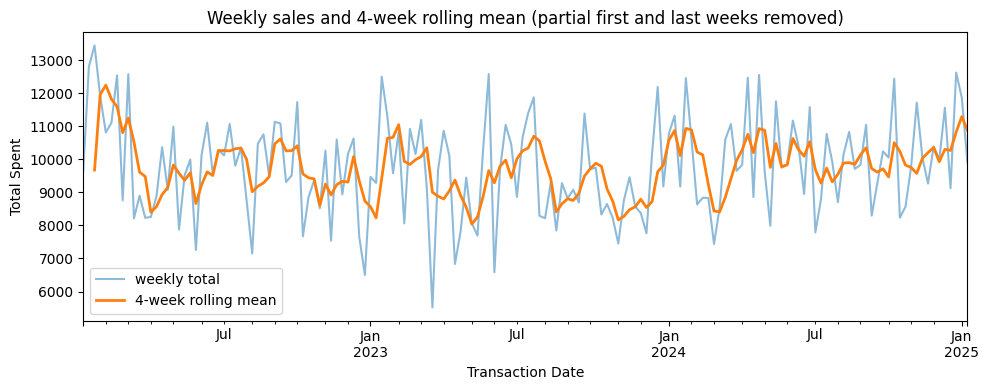

In [156]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
weekly.iloc[1:-1].plot(ax=ax, alpha=0.5, label="weekly total")
rolling_mean.iloc[1:-1].plot(ax=ax, linewidth=2, label="4-week rolling mean")
ax.set_title("Weekly sales and 4-week rolling mean (partial first and last weeks removed)")
ax.set_ylabel("Total Spent")
ax.legend()
plt.tight_layout()
plt.show()

*The pale line is noisy week to week; the thick line shows the underlying level. The first and last weeks are left out because they are partial.*

## 8.6 The challenge: sales trend analyst

*The manager asks for a time-based sales summary. Sections A to D are code; E is the interpretation.*

**Q68.** **A. Date preparation:** confirm the date column is datetime and count invalid dates. **B. Date components:** show `Year`, `Month`, `Day Name`.

In [157]:
print(sales["Transaction Date"].dtype, "| invalid dates:", sales["Transaction Date"].isna().sum())

sales["Year"] = sales["Transaction Date"].dt.year
sales["Month"] = sales["Transaction Date"].dt.month
sales["Day Name"] = sales["Transaction Date"].dt.day_name()
sales[["Transaction Date", "Year", "Month", "Day Name"]].head(3)

datetime64[us] | invalid dates: 0


,Transaction Date,Year,Month,Day Name
0,2024-04-08,2024,4,Monday
1,2023-07-23,2023,7,Sunday
2,2022-10-05,2022,10,Wednesday


**Q69.** **C. Weekly reporting** and **D. Rolling analysis:** build the weekly Series with the 4-week rolling mean and standard deviation, and summarise the full weeks only.

In [158]:
full_weeks = weekly.iloc[1:-1]                       # drop the partial first and last weeks
summary = pd.DataFrame({
    "weekly_sales": full_weeks,
    "rolling_mean_4w": full_weeks.rolling(4).mean(),
    "rolling_std_4w": full_weeks.rolling(4).std(),
})
print(summary.describe().round(1))

       weekly_sales  rolling_mean_4w  rolling_std_4w
count         158.0            155.0           155.0
mean         9762.0           9734.6          1300.5
std          1476.8            813.8           521.7
min          5519.0           8038.6           264.8
25%          8757.5           9223.5           903.8
50%          9702.8           9751.5          1296.4
75%         10803.4          10264.2          1651.3
max         13441.0          12241.6          2689.0


**Q70.** **E. Interpretation:** what do the weekly sales and rolling measures tell a manager? (The numbers below are computed from the data.)

In [159]:
from IPython.display import Markdown, display

mean_w, std_w = full_weeks.mean(), full_weeks.std()
best, worst = full_weeks.idxmax(), full_weeks.idxmin()
rm = summary["rolling_mean_4w"].dropna()

# Is there a long-run trend? Fit a straight line through the weekly totals.
slope, _ = np.polyfit(np.arange(len(full_weeks)), full_weeks.values, 1)
drift = slope * len(full_weeks) / mean_w          # total change over the period, as a share of the average week

if abs(drift) < 0.10:
    trend_txt = (f"A straight-line fit changes by only {drift:+.1%} over the whole period, so there is no clear long-run growth or decline. "
                 "The rolling mean still swings up and down; those look like short waves (seasons, promotions) rather than a sustained trend.")
else:
    trend_txt = f"A straight-line fit changes by {drift:+.1%} over the period, so sales are trending and that is worth investigating."

display(Markdown(f'''
1. A typical full week brings in about **{mean_w:,.0f}**, with week-to-week swings of roughly **{std_w:,.0f}** ({std_w/mean_w:.0%} of the average), so single weeks are noisy.
2. The strongest week ended **{best.date()}** at {full_weeks.max():,.0f} and the weakest ended **{worst.date()}** at {full_weeks.min():,.0f}. A manager should check for events (promotions, holidays, stock-outs) around those dates.
3. {trend_txt} The 4-week rolling mean ranges from {rm.min():,.0f} to {rm.max():,.0f}.
4. The rolling standard deviation tells us when sales are *volatile*: high values mean unpredictable weeks that make stock planning harder.
5. Caveat: the data contains missing `Total Spent` values that `sum` skips, so true sales are slightly higher than shown.
'''))


1. A typical full week brings in about **9,762**, with week-to-week swings of roughly **1,477** (15% of the average), so single weeks are noisy.
2. The strongest week ended **2022-01-23** at 13,441 and the weakest ended **2023-03-19** at 5,519. A manager should check for events (promotions, holidays, stock-outs) around those dates.
3. A straight-line fit changes by only +1.4% over the whole period, so there is no clear long-run growth or decline. The rolling mean still swings up and down; those look like short waves (seasons, promotions) rather than a sustained trend. The 4-week rolling mean ranges from 8,039 to 12,242.
4. The rolling standard deviation tells us when sales are *volatile*: high values mean unpredictable weeks that make stock planning harder.
5. Caveat: the data contains missing `Total Spent` values that `sum` skips, so true sales are slightly higher than shown.


*Business reading, not code description: the rolling mean answers "where is the level?" and the rolling standard deviation answers "how much can I trust next week to look like this one?".*

## 8.7 Optional homework, answered

**Q71.** **Homework 2 to 4:** total sales by year, by month (across all years), and by day of the week.

In [160]:
print("By year:\n", sales.groupby("Year")["Total Spent"].sum(), "\n")
print("By month (all years):\n", sales.groupby("Transaction Month")["Total Spent"].sum().round(1), "\n")
print("By day of week:\n", by_day)

By year:
 Year
2022    510329.5
2023    491312.0
2024    524881.0
2025     25548.5
Name: Total Spent, dtype: float64 

By month (all years):
 Transaction Month
1     174421.0
2     119685.0
3     122392.0
4     125618.5
5     124594.5
6     129771.0
7     131509.0
8     123287.5
9     129344.0
10    119413.5
11    122346.5
12    129688.5
Name: Total Spent, dtype: float64 

By day of week:
 Transaction Day
Monday       213090.5
Tuesday      219650.0
Wednesday    216982.0
Thursday     219380.5
Friday       232786.0
Saturday     224191.0
Sunday       225991.0
Name: Total Spent, dtype: float64


*2025 holds only 18 days of data, so its total is small because the data stops early, not because sales fell. Monthly totals here add all years together, so months that appear in 2025 (January) get four years of data while others get three, which flatters January.*

**Q72.** **Homework 8 and 9:** explain `resample()` vs `rolling()` and downsampling vs upsampling in your own words.

*`resample()` **changes the time frequency**: many daily rows become one weekly row, and each output row covers a separate period. `rolling()` **keeps every row** and calculates a statistic over a moving window of neighbouring observations, so the windows overlap.*

*Downsampling moves to a coarser frequency (daily → weekly) by summarising rows, so information is combined. Upsampling moves to a finer frequency (weekly → daily) by creating new time points, so any filled value is an assumption rather than a real measurement.*

## 8.8 Common beginner mistakes (from the trainer's list)

# PART 9 — COMMON BEGINNER MISTAKES

## Mistake 1 — Treating dates as ordinary strings

```python
sales["Transaction Date"].dt.year
```

will not work properly if the column has not been converted to datetime.

**Fix:**

```python
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])
```

---

## Mistake 2 — Using `resample()` without a time-aware index

`resample()` expects a time-based index or an appropriate time-based selection.

A common beginner workflow is:

```python
sales.set_index("Transaction Date")
```

but forgetting to save the result.

Remember:

```python
sales_time = sales.set_index("Transaction Date")
```

---

## Mistake 3 — Confusing `resample()` and `rolling()`

They are both time-related, but they do different jobs.

- `resample("W")` → creates **weekly groups**.
- `rolling(7)` → creates a **moving 7-observation window**.

A useful memory trick:

> **Resample changes the time frequency. Rolling moves a window across the data.**

---

## Mistake 4 — Thinking upsampling creates new information

Upsampling creates new time points. It does not create real measurements that were never recorded.

Any filling or interpolation step needs to make sense for the meaning of the data.

---

## Mistake 5 — Forgetting what the rolling window represents

```python
rolling(7)
```

means **7 observations**, not automatically "7 calendar days" in every situation.

If your data has missing dates or irregular observations, this distinction matters.

---
# PART 9 — EXTRA PRACTICE ON NEW EXAMPLES

Everything so far used the retail data. Here is a **different dataset**, a small Kenyan supermarket generated with a fixed seed, so you meet the same skills on new ground. Solved examples come first; **Your turn** cells at the end are blank for independent practice.

## 9.1 Build the mini-market data

**Q73.** Generate 900 sales rows for four branches and six products, plus a small branch information table.

In [161]:
rng = np.random.default_rng(2024)

products = pd.DataFrame({
    "product": ["Unga (2kg)", "Milk (500ml)", "Sugar (1kg)", "Rice (1kg)", "Cooking Oil (1L)", "Bread"],
    "unit_price": [190, 60, 165, 210, 320, 65],
})
branches = ["Nairobi CBD", "Westlands", "Kisumu", "Mombasa"]

n = 900
mm = pd.DataFrame({
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 182, n), unit="D"),
    "branch": rng.choice(branches, n),
    "product": rng.choice(products["product"], n),
    "units": rng.integers(1, 12, n),
    "payment": rng.choice(["M-Pesa", "Cash", "Card"], n, p=[0.55, 0.30, 0.15]),
})
mm = mm.merge(products, on="product")
mm["revenue"] = mm["units"] * mm["unit_price"]

branch_info = pd.DataFrame({
    "branch": ["Nairobi CBD", "Westlands", "Kisumu", "Nakuru"],
    "manager": ["Amina", "Brian", "Carol", "Dennis"],
})
print(mm.shape)
mm.head()

(900, 7)


,date,branch,product,units,payment,unit_price,revenue
0,2024-02-13,Kisumu,Milk (500ml),10,Cash,60,600
1,2024-05-03,Westlands,Sugar (1kg),4,Cash,165,660
2,2024-01-17,Nairobi CBD,Cooking Oil (1L),4,Card,320,1280
3,2024-02-09,Mombasa,Cooking Oil (1L),2,M-Pesa,320,640
4,2024-02-27,Nairobi CBD,Bread,4,M-Pesa,65,260


*The random generator has a fixed seed, so everyone gets identical data. `Nakuru` appears in `branch_info` but not in the sales, and `Mombasa` appears in the sales but not in `branch_info`. That mismatch is deliberate; it makes the join exercise interesting.*

## 9.2 Inspect and filter

**Q74.** Inspect the data, then filter M-Pesa sales of 8 or more units.

In [162]:
mm.info()
print()
print("missing values:", mm.isna().sum().sum())
mpesa_big = mm[(mm["payment"] == "M-Pesa") & (mm["units"] >= 8)]
print("M-Pesa sales with 8+ units:", mpesa_big.shape[0])

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        900 non-null    datetime64[us]
 1   branch      900 non-null    str           
 2   product     900 non-null    str           
 3   units       900 non-null    int64         
 4   payment     900 non-null    str           
 5   unit_price  900 non-null    int64         
 6   revenue     900 non-null    int64         
dtypes: datetime64[us](1), int64(3), str(3)
memory usage: 49.3 KB

missing values: 0
M-Pesa sales with 8+ units: 194


*No missing values in this clean data. The filter follows the same pattern as Part 3: each condition in parentheses, joined with `&`.*

## 9.3 Aggregate

**Q75.** Total revenue per product, sorted, and the best-selling product.

In [163]:
rev = mm.groupby("product")["revenue"].sum().sort_values(ascending=False)
print(rev)
print("best product:", rev.idxmax(), f"(Ksh {rev.max():,})")

product
Cooking Oil (1L)    277760
Rice (1kg)          185430
Sugar (1kg)         165330
Unga (2kg)          148580
Bread                72670
Milk (500ml)         48300
Name: revenue, dtype: int64
best product: Cooking Oil (1L) (Ksh 277,760)


**Q76.** Named aggregation per branch: revenue, average sale, number of sales, distinct products.

In [164]:
branch_summary = (
    mm.groupby("branch")
    .agg(revenue=("revenue", "sum"),
         avg_sale=("revenue", "mean"),
         sales=("revenue", "count"),
         products=("product", "nunique"))
    .round(0)
    .reset_index()
)
branch_summary

,branch,revenue,avg_sale,sales,products
0,Kisumu,219625,968.0,227,6
1,Mombasa,256990,1016.0,253,6
2,Nairobi CBD,213720,989.0,216,6
3,Westlands,207735,1018.0,204,6


**Q77.** Use `transform` to show each row's revenue as a percentage of its branch's total.

In [165]:
mm["pct_of_branch"] = (mm["revenue"] / mm.groupby("branch")["revenue"].transform("sum") * 100).round(3)
print(mm.groupby("branch")["pct_of_branch"].sum().round(1))     # each branch should add to 100
mm[["branch", "product", "revenue", "pct_of_branch"]].head()

branch
Kisumu         100.0
Mombasa        100.0
Nairobi CBD    100.0
Westlands      100.0
Name: pct_of_branch, dtype: float64


,branch,product,revenue,pct_of_branch
0,Kisumu,Milk (500ml),600,0.273
1,Westlands,Sugar (1kg),660,0.318
2,Nairobi CBD,Cooking Oil (1L),1280,0.599
3,Mombasa,Cooking Oil (1L),640,0.249
4,Nairobi CBD,Bread,260,0.122


*The check works: each branch's percentages sum to 100. Whenever you build a share, add up the shares to confirm.*

## 9.4 Reshape

**Q78.** Pivot: revenue by product (rows) and branch (columns), with totals.

In [166]:
pt = pd.pivot_table(mm, values="revenue", index="product", columns="branch", aggfunc="sum", margins=True, margins_name="Total")
pt

branch,Kisumu,Mombasa,Nairobi CBD,Westlands,Total
product,,,,,
Bread,17680,20995,19435,14560,72670
Cooking Oil (1L),65600,90240,61120,60800,277760
Milk (500ml),10620,15480,11520,10680,48300
Rice (1kg),44100,46410,49980,44940,185430
Sugar (1kg),38115,43395,42405,41415,165330
Unga (2kg),43510,40470,29260,35340,148580
Total,219625,256990,213720,207735,898070


**Q79.** Crosstab: within each branch, what share of sales used each payment method?

In [167]:
(pd.crosstab(mm["branch"], mm["payment"], normalize="index") * 100).round(1)

payment,Card,Cash,M-Pesa
branch,,,
Kisumu,15.4,32.2,52.4
Mombasa,14.6,30.0,55.3
Nairobi CBD,15.3,25.9,58.8
Westlands,14.7,26.0,59.3


**Q80.** Melt the branch summary so it has one row per branch and metric.

In [168]:
branch_summary.melt(id_vars="branch", var_name="metric", value_name="value")

,branch,metric,value
0,Kisumu,revenue,219625.0
1,Mombasa,revenue,256990.0
2,Nairobi CBD,revenue,213720.0
3,Westlands,revenue,207735.0
4,Kisumu,avg_sale,968.0
5,Mombasa,avg_sale,1016.0
6,Nairobi CBD,avg_sale,989.0
7,Westlands,avg_sale,1018.0
8,Kisumu,sales,227.0
9,Mombasa,sales,253.0


## 9.5 Combine

**Q81.** Add the manager to each branch's summary with a left join, then find branches with no manager on file. Then outer-join to find managers with no sales.

In [169]:
left = branch_summary.merge(branch_info, on="branch", how="left")
print(left[["branch", "revenue", "manager"]])
print("\nBranches with no manager on file:", left.loc[left["manager"].isna(), "branch"].tolist())

outer = branch_summary.merge(branch_info, on="branch", how="outer", indicator=True)
print("\nManagers with no sales:", outer.loc[outer["_merge"] == "right_only", "manager"].tolist())

        branch  revenue manager
0       Kisumu   219625   Carol
1      Mombasa   256990     NaN
2  Nairobi CBD   213720   Amina
3    Westlands   207735   Brian

Branches with no manager on file: ['Mombasa']

Managers with no sales: ['Dennis']


*A left join keeps every branch in the sales summary, with NaN where the manager is unknown (Mombasa). An outer join with `indicator=True` reveals rows on only one side: Nakuru's manager Dennis has no sales.*

## 9.6 Time series

**Q82.** Weekly revenue, monthly revenue, and a 4-week rolling mean. Which month was strongest?

In [170]:
ts = mm.set_index("date").sort_index()
weekly_mm = ts["revenue"].resample("W").sum()
monthly_mm = ts["revenue"].resample("ME").sum()

print(monthly_mm)
print("\nstrongest month:", monthly_mm.idxmax().strftime("%B %Y"))
print("\nweekly + 4-week rolling mean:")
print(pd.DataFrame({"weekly": weekly_mm, "roll4": weekly_mm.rolling(4).mean().round(0)}).head(8))

date
2024-01-31    171460
2024-02-29    151270
2024-03-31    161095
2024-04-30    146910
2024-05-31    126750
2024-06-30    140585
Freq: ME, Name: revenue, dtype: int64

strongest month: January 2024

weekly + 4-week rolling mean:
            weekly    roll4
date                       
2024-01-07   49505      NaN
2024-01-14   34220      NaN
2024-01-21   28860      NaN
2024-01-28   45020  39401.0
2024-02-04   32580  35170.0
2024-02-11   38395  36214.0
2024-02-18   32875  37218.0
2024-02-25   36965  35204.0


*Same three-step recipe as Part 8: `set_index` on the date, `resample` to change the frequency, then `rolling` to smooth.*

## 9.7 Your turn (blank cells for independent practice)

Try these on `mm`, `products` and `branch_info`. Write your answer in the cell below each task, then compare your result with a partner or with me.

1. Which **payment method** brings in the most revenue, and what share of total revenue is that?
2. Which **product and branch pair** has the highest revenue? (Hint: `groupby` two columns, then `nlargest`.)
3. Create a column `size` that labels each sale `"Small"` (revenue < 300), `"Medium"` (300 to 999) or `"Large"` (1000+). (Hint: `pd.cut`.)
4. Make a pivot table of average `units` by `branch` and `payment`.
5. Find the **busiest day of the week** by number of sales.
6. Merge `products` back onto a summary of units sold per product and compute revenue from `units × unit_price`.
7. Compute a **4-week rolling standard deviation** of weekly revenue for one branch only.

In [171]:
# 1.

In [172]:
# 2.

In [173]:
# 3.

In [174]:
# 4.

In [175]:
# 5.

In [176]:
# 6.

In [177]:
# 7.

---
# PART 10 — CHEAT SHEET AND REFLECTION

## The big picture

```text
NUMPY            arrays, shape, dtype, slicing, broadcasting, np.where
   ↓
PANDAS BASICS    Series, DataFrame, read_csv / to_csv, dtypes
   ↓
INSPECT          shape, info, describe, head, isna, value_counts
SELECT           df[col], df[[cols]], .loc (labels), .iloc (positions)
FILTER           masks with & | ~, isin, between, query
   ↓
CLEAN            dropna, fillna, drop_duplicates, rename, astype, .str
   ↓
AGGREGATE        groupby / agg / transform
RESHAPE          pivot_table / crosstab / melt
COMBINE          merge (on a key) / concat (stack)
   ↓
TIME             to_datetime, .dt, set_index, resample (frequency), rolling (window)
```

## Quick reference

| I want to... | Use |
|---|---|
| Count missing values | `df.isna().sum()` |
| Keep rows that match two conditions | `df[(cond1) & (cond2)]` |
| Total by group | `df.groupby("col")["value"].sum()` |
| Several summaries with clear names | `.agg(name=("col", "func"))` |
| Group value on every row | `.groupby(...)[col].transform("mean")` |
| Rows × columns summary | `pd.pivot_table(...)` or `pd.crosstab(...)` |
| Wide → long | `df.melt(id_vars=...)` |
| Add info from another table | `df.merge(other, on="key", how="left")` |
| Stack same-shaped tables | `pd.concat([a, b], ignore_index=True)` |
| Text → dates | `pd.to_datetime(col, errors="coerce")` |
| Weekly / monthly totals | `s.resample("W").sum()` / `s.resample("ME").sum()` |
| Moving average | `s.rolling(4).mean()` |

## Five habits to keep

1. **Check the shape** right after loading anything.
2. **Save your result** to a variable, or the change is lost.
3. **Missing values fail silently**: masks skip them, `count` ignores them. Check `isna()` first.
4. **`.copy()`** before editing a slice or a filtered result.
5. **Ask what a row represents** before choosing an operation.

## Reflection

- Which topic took longest to click, and what finally made it clear?
- Which error from my early notebooks was hardest to spot, and why?
- What would I do differently the next time I meet a messy dataset?

---
*Prepared by Benson M. Merita — Tech Savvy Institute, Python for Data Analysis, Module 2.*